In [1]:
import os
import librosa
emodb_path = "../data/emoDB/wav"
print(os.listdir(emodb_path)[:5])

['13a05Nb.wav', '11b10Ad.wav', '14a07Ld.wav', '10b10Fc.wav', '12a01Nb.wav']


In [2]:
# mapping the emotions
def map_emodb_emotion(code):
    mapping = {
        'W': 'angry',
        'L': 'boredom',
        'E': 'disgust',
        'A': 'fear',
        'F': 'happy',
        'T': 'sad',
        'N': 'neutral'
    }
    return mapping.get(code)

In [3]:
def parse_emodb_filename(filename):
    speaker_id = filename[:2]
    emotion_code = filename[5]
    
    emotion = map_emodb_emotion(emotion_code)
    
    return speaker_id, emotion
import pandas as pd

data = []

for file in os.listdir(emodb_path):
    if file.endswith(".wav"):
        speaker, emotion = parse_emodb_filename(file)
        
        data.append({
            "file": file,
            "speaker": speaker,
            "emotion": emotion
        })

df = pd.DataFrame(data)

print(df.head())

          file speaker  emotion
0  13a05Nb.wav      13  neutral
1  11b10Ad.wav      11     fear
2  14a07Ld.wav      14  boredom
3  10b10Fc.wav      10    happy
4  12a01Nb.wav      12  neutral


gender   female  male
emotion              
angry        67    60
boredom      46    35
disgust      35    11
fear         33    36
happy        44    27
neutral      40    39
sad          37    25


/home/nida/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


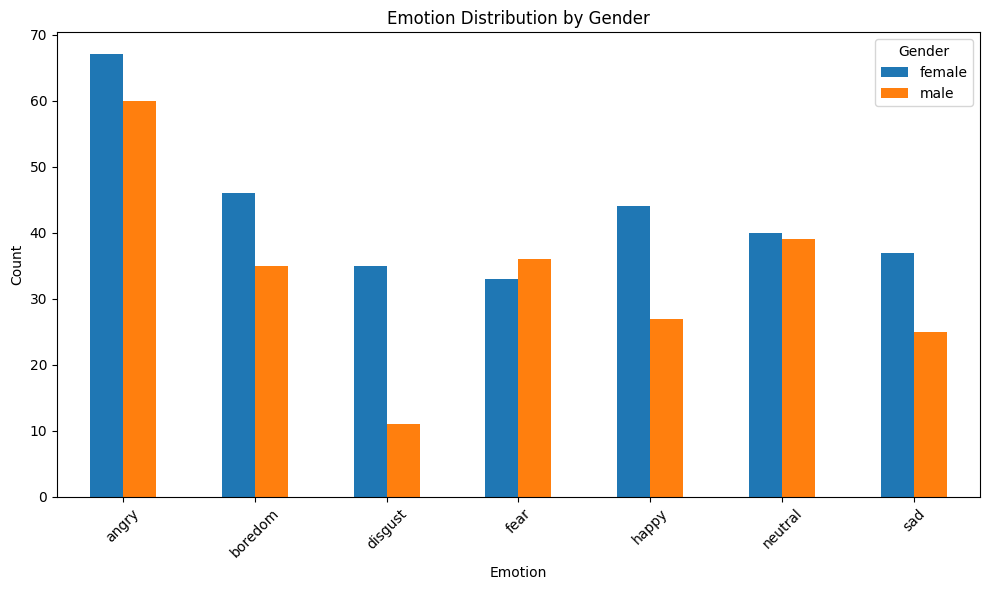

In [4]:
# visualization of emotions and speaker

speaker_gender = {
    '03': 'male',
    '08': 'female',
    '09': 'female',
    '10': 'male',
    '11': 'male',
    '12': 'male',
    '13': 'female',
    '14': 'female',
    '15': 'male',
    '16': 'female'
}
df["gender"] = df["speaker"].map(speaker_gender)

# print(df.head())

gender_emotion_counts = df.groupby(["emotion", "gender"]).size().unstack()

print(gender_emotion_counts)
import matplotlib.pyplot as plt

gender_emotion_counts.plot(kind='bar', figsize=(10, 6))

plt.title("Emotion Distribution by Gender")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()

plt.show()

gender
female    302
male      233
Name: count, dtype: int64


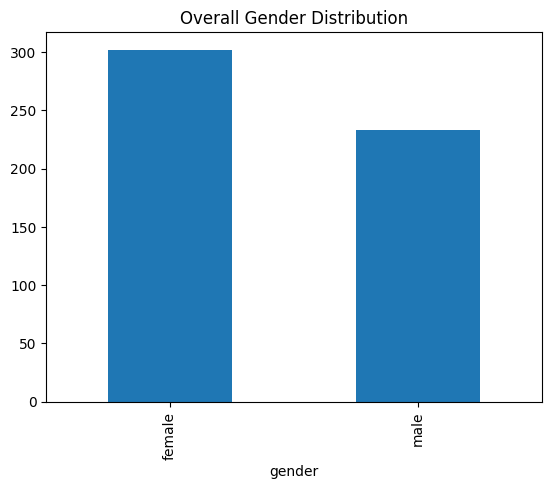

In [5]:
print(df["gender"].value_counts())
df["gender"].value_counts().plot(kind='bar')
plt.title("Overall Gender Distribution")
plt.show()

In [6]:
# augmentation functions .. added data augmentations to make 130 samples each

import numpy as np
import librosa

def add_noise(signal):
    noise = np.random.normal(0, 0.003, len(signal))  # reduced noise
    return signal + noise

def time_stretch(signal):
    rate = np.random.uniform(0.9, 1.1)  # random mild stretch
    return librosa.effects.time_stretch(signal, rate=rate)

def time_shift(signal):
    shift = np.random.randint(len(signal) * 0.1)
    return np.roll(signal, shift)

def change_gain(signal):
    gain = np.random.uniform(0.8, 1.2)
    return signal * gain

import os
import librosa
from collections import Counter

target_count = 130

X_audio = []
y_audio = []

for emotion in df["emotion"].unique():
    
    emotion_files = df[df["emotion"] == emotion]
    count = len(emotion_files)
    
    print(f"{emotion}: {count} original samples")
    
    # Add original samples
    for _, row in emotion_files.iterrows():
        file_path = os.path.join(emodb_path, row["file"])
        signal, sr = librosa.load(file_path, sr=16000)
        
        X_audio.append(signal)
        y_audio.append(emotion)
    
    # Number of augmented samples needed
    needed = target_count - count
    
    i = 0
    while needed > 0:
        row = emotion_files.iloc[i % len(emotion_files)]
        file_path = os.path.join(emodb_path, row["file"])
        
        signal, sr = librosa.load(file_path, sr=16000)
        
        # Random augmentation WITHOUT pitch change
        aug_type = np.random.choice(["noise", "stretch", "shift", "gain"])
        
        if aug_type == "noise":
            aug_signal = add_noise(signal)
        elif aug_type == "stretch":
            aug_signal = time_stretch(signal)
        elif aug_type == "shift":
            aug_signal = time_shift(signal)
        else:
            aug_signal = change_gain(signal)
        
        X_audio.append(aug_signal)
        y_audio.append(emotion)
        
        needed -= 1
        i += 1
print('after data augmentation:')
print("Total samples:", len(X_audio))
print("Class distribution:", Counter(y_audio))

neutral: 79 original samples
fear: 69 original samples
boredom: 81 original samples
happy: 71 original samples
sad: 62 original samples
angry: 127 original samples
disgust: 46 original samples
after data augmentation:
Total samples: 910
Class distribution: Counter({'neutral': 130, 'fear': 130, 'boredom': 130, 'happy': 130, 'sad': 130, 'angry': 130, 'disgust': 130})


In [7]:
# Extracting mfcc on entire speech signal

def extract_mfcc(signal, sr=16000, n_mfcc=26, max_len=200):
    
    # Normalize
    if np.max(np.abs(signal)) > 0:
        signal = signal / np.max(np.abs(signal))
    
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
    mfcc = mfcc.T
    
    # Padding / trimming
    if mfcc.shape[0] < max_len:
        mfcc = np.pad(mfcc, ((0, max_len - mfcc.shape[0]), (0, 0)))
    else:
        mfcc = mfcc[:max_len]
    
    return mfcc

X_mfcc = []

for signal in X_audio:
    mfcc = extract_mfcc(signal)
    X_mfcc.append(mfcc)

X_mfcc = np.array(X_mfcc)
y = np.array(y_audio)

print("Shape:", X_mfcc.shape)

Shape: (910, 200, 26)


In [8]:
from collections import Counter
print(Counter(y))
X_flat = X_mfcc.reshape(X_mfcc.shape[0], -1)

print("Flattened shape:", X_flat.shape)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(le.classes_)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

Counter({'neutral': 130, 'fear': 130, 'boredom': 130, 'happy': 130, 'sad': 130, 'angry': 130, 'disgust': 130})
Flattened shape: (910, 5200)
['angry' 'boredom' 'disgust' 'fear' 'happy' 'neutral' 'sad']


In [9]:
import numpy as np

# indices of all samples
indices = np.arange(len(y))
angry_indices = indices[y == 'angry']
other_indices = indices[y != 'angry']
np.random.seed(42)  # reproducibility

selected_angry = np.random.choice(angry_indices, size=90, replace=False)
final_indices = np.concatenate([selected_angry, other_indices])
X_mfcc_balanced = X_mfcc[final_indices]
y_balanced = y[final_indices]
from sklearn.utils import shuffle

X_mfcc_balanced, y_balanced = shuffle(X_mfcc_balanced, y_balanced, random_state=42)
from collections import Counter

print(Counter(y_balanced))
print("New shape:", X_mfcc_balanced.shape)

Counter({'boredom': 130, 'happy': 130, 'disgust': 130, 'fear': 130, 'neutral': 130, 'sad': 130, 'angry': 90})
New shape: (870, 200, 26)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
svm.fit(X_train, y_train)
from sklearn.metrics import classification_report

y_pred = svm.predict(X_test)

print("Accuracy:", svm.score(X_test, y_test))
print(classification_report(y_test, y_pred))

Accuracy: 0.8296703296703297
              precision    recall  f1-score   support

           0       0.85      0.92      0.88        25
           1       0.81      0.72      0.76        36
           2       0.95      0.88      0.91        24
           3       0.85      0.96      0.90        24
           4       0.87      0.57      0.68        23
           5       0.72      0.85      0.78        27
           6       0.81      0.96      0.88        23

    accuracy                           0.83       182
   macro avg       0.84      0.84      0.83       182
weighted avg       0.84      0.83      0.83       182



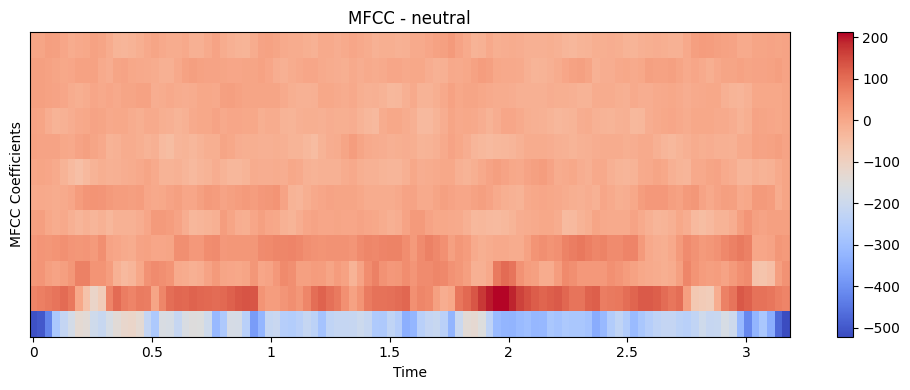

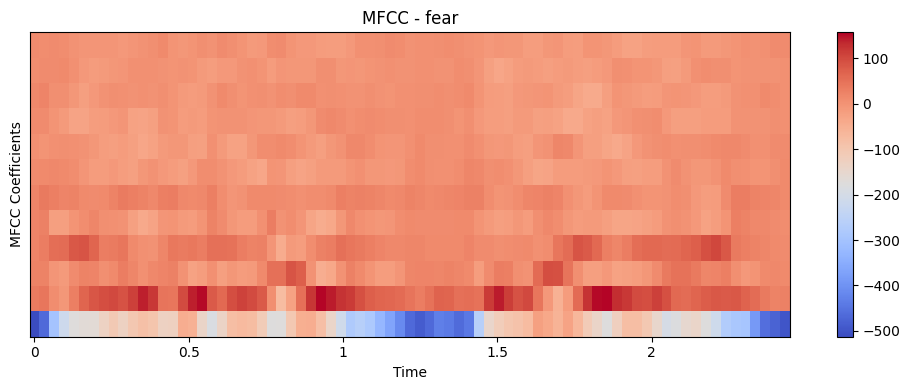

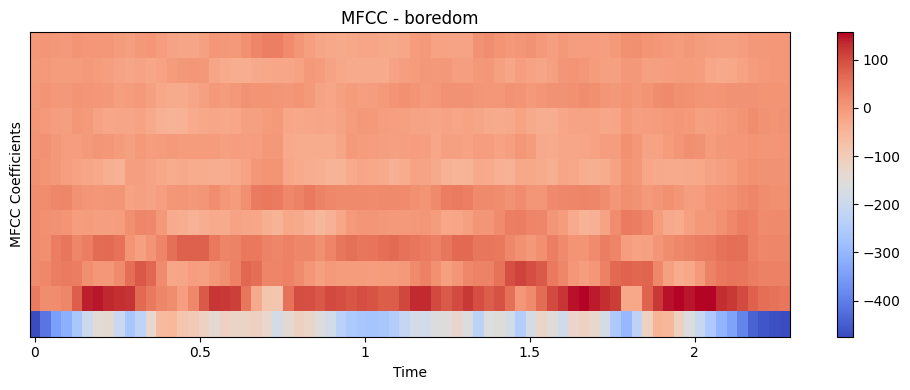

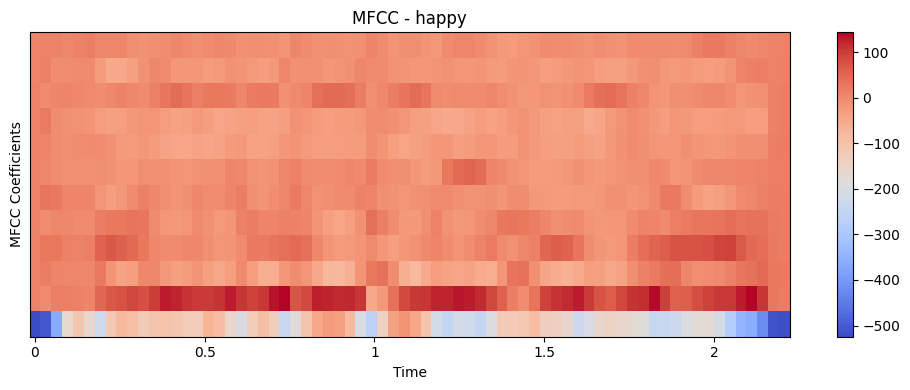

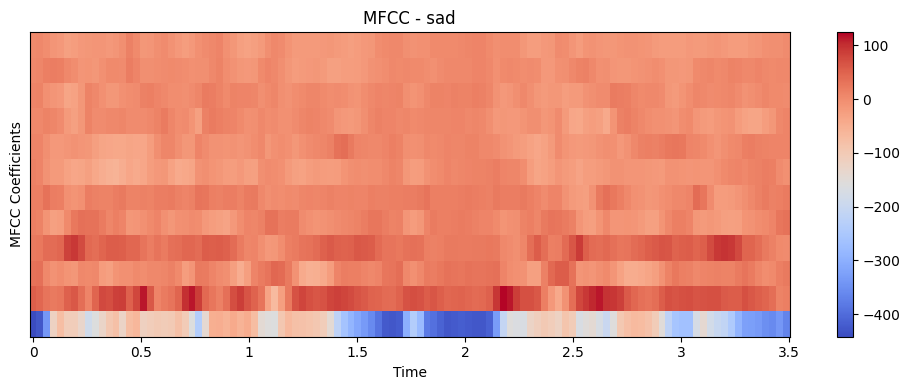

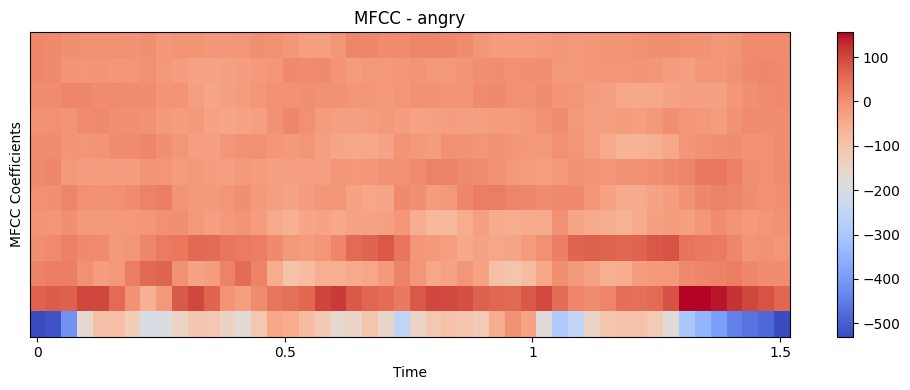

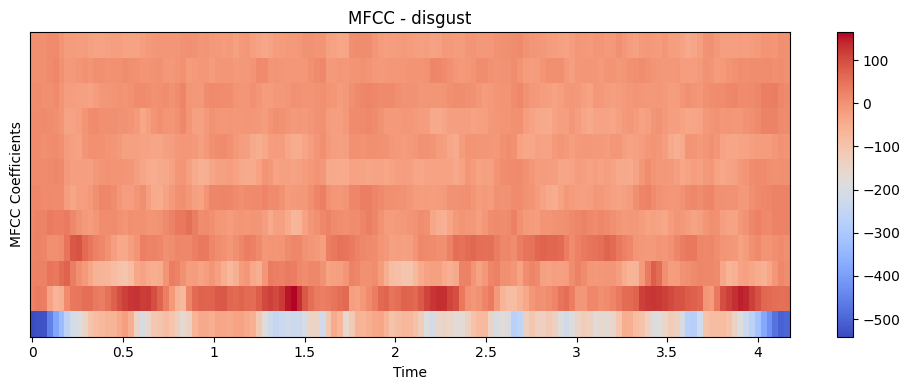

In [11]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Pick one sample per emotion
sample_files = {}

for emotion in df["emotion"].unique():
    file_row = df[df["emotion"] == emotion].iloc[0]
    sample_files[emotion] = os.path.join(emodb_path, file_row["file"])


# Plot MFCCs
for emotion, file_path in sample_files.items():
    
    signal, sr = librosa.load(file_path, sr=16000)
    
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=12)
    
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc, x_axis='time', sr=sr)
    plt.colorbar()
    
    plt.title(f"MFCC - {emotion}")
    plt.xlabel("Time")
    plt.ylabel("MFCC Coefficients")
    
    plt.tight_layout()
    plt.show()

## Vowel Regions:

Extracting vowel-region features...


/home/nida/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1536
  warnings.warn(
/home/nida/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1920
  warnings.warn(
/home/nida/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=896
  warnings.warn(
/home/nida/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1152
  warnings.warn(
/home/nida/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1280
  warnings.warn(
/home/nida/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1024
  warnings.warn(
/home/nida/.local/lib/p

Vowel feature shape: (910, 270)
Fused feature shape: (910, 5470)

Full-signal MFCCs (baseline)  —  Accuracy: 0.8297
              precision    recall  f1-score   support

       angry       0.85      0.92      0.88        25
     boredom       0.81      0.72      0.76        36
     disgust       0.95      0.88      0.91        24
        fear       0.85      0.96      0.90        24
       happy       0.87      0.57      0.68        23
     neutral       0.72      0.85      0.78        27
         sad       0.81      0.96      0.88        23

    accuracy                           0.83       182
   macro avg       0.84      0.84      0.83       182
weighted avg       0.84      0.83      0.83       182


Vowel-region features only  —  Accuracy: 0.7692
              precision    recall  f1-score   support

       angry       0.68      0.84      0.75        25
     boredom       0.77      0.64      0.70        36
     disgust       0.88      0.88      0.88        24
        fear       0.

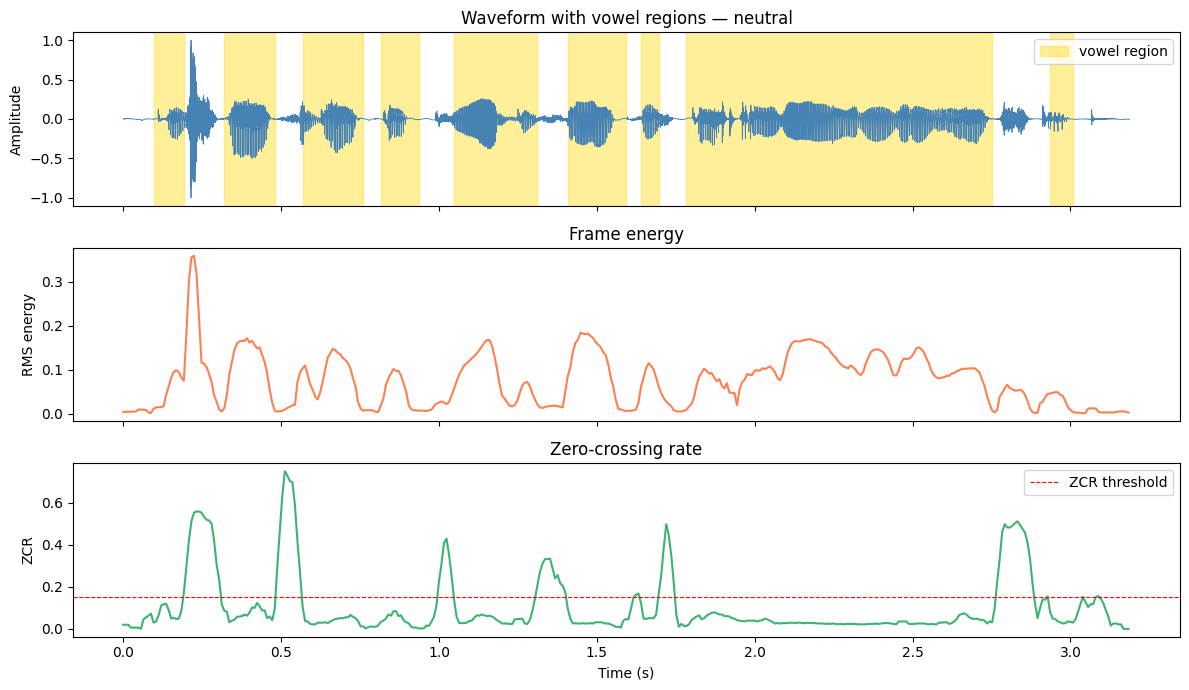

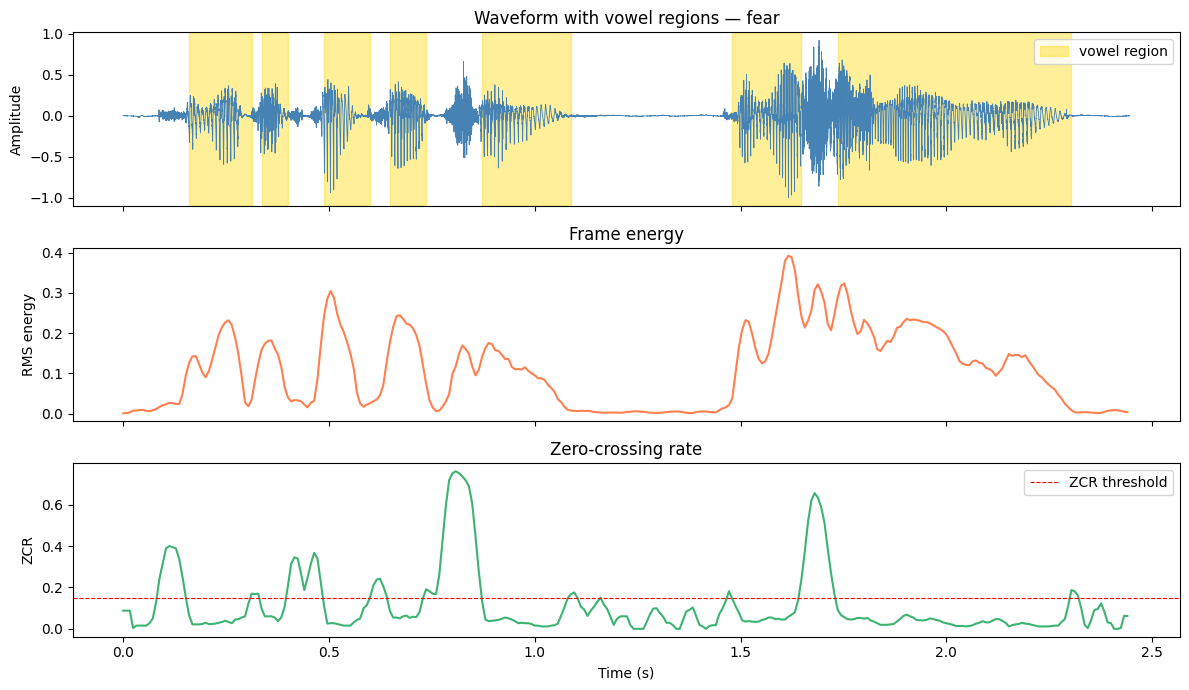

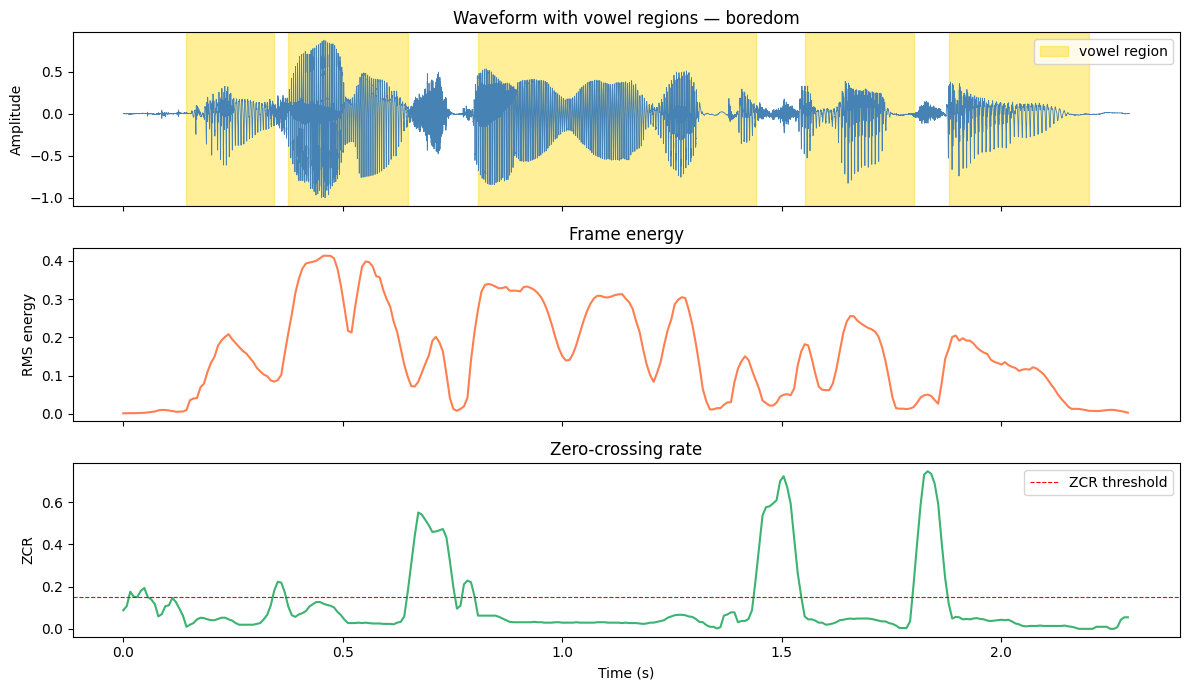

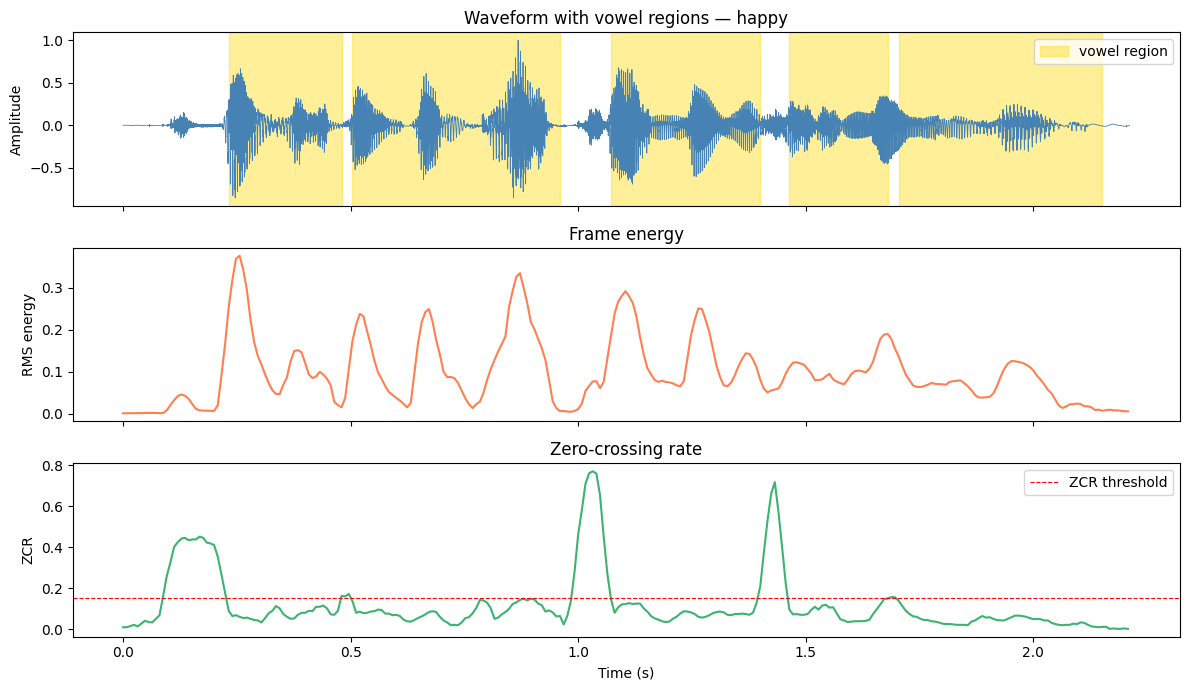

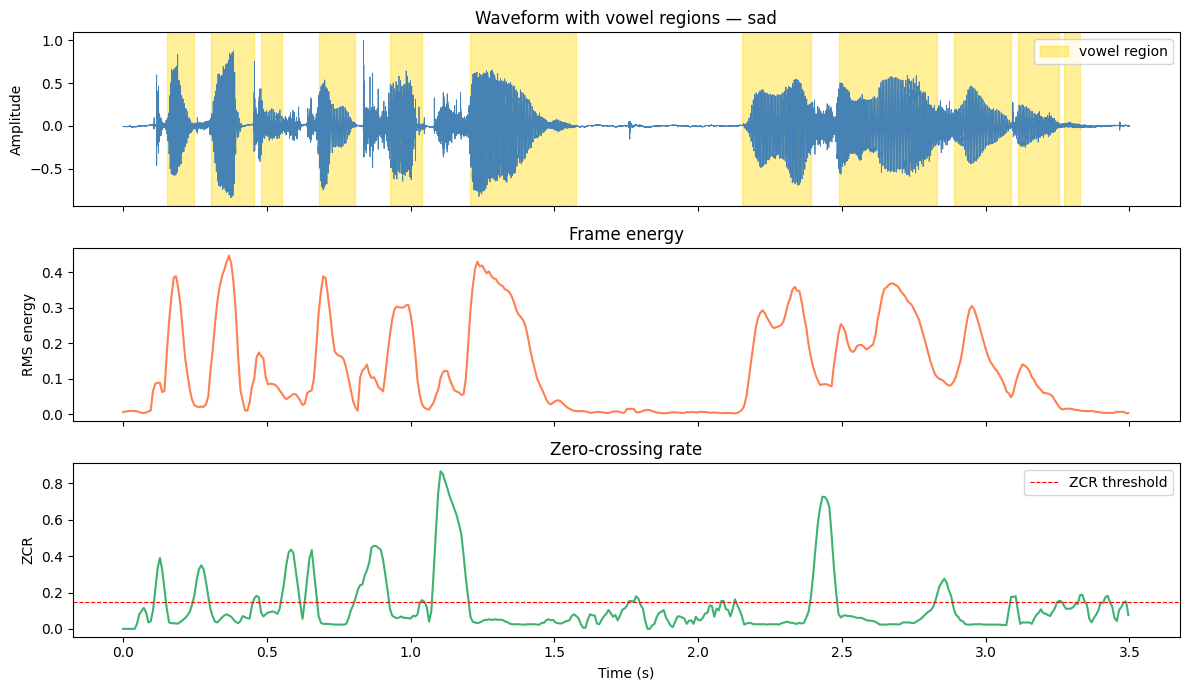

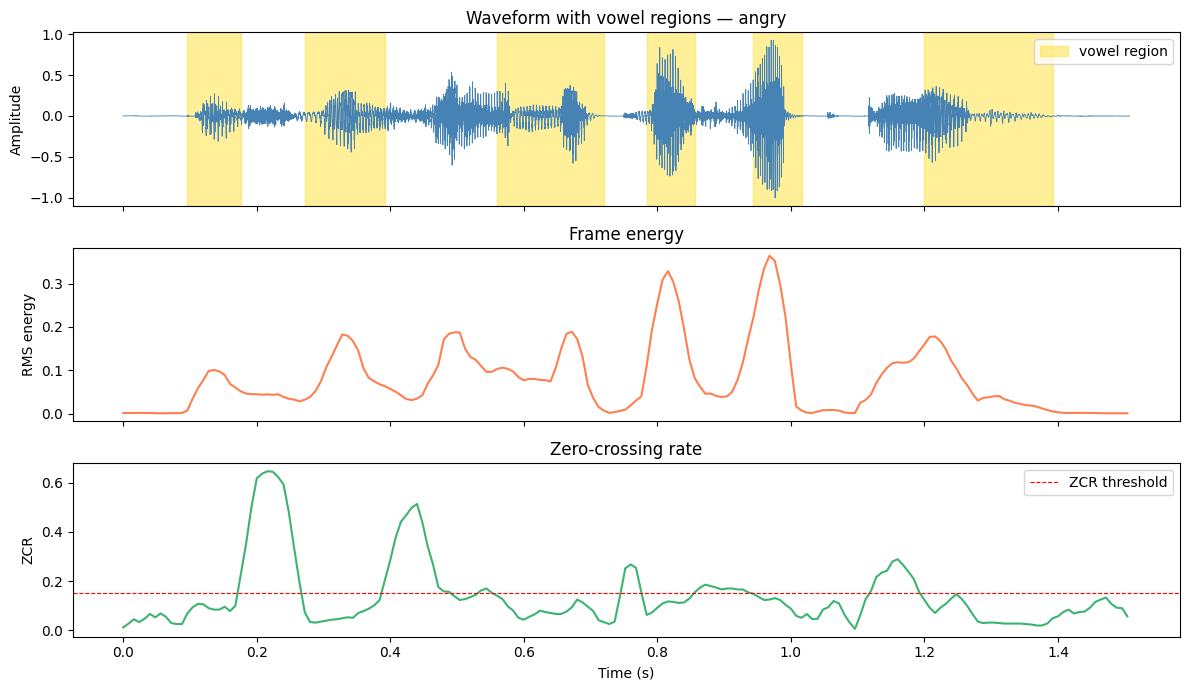

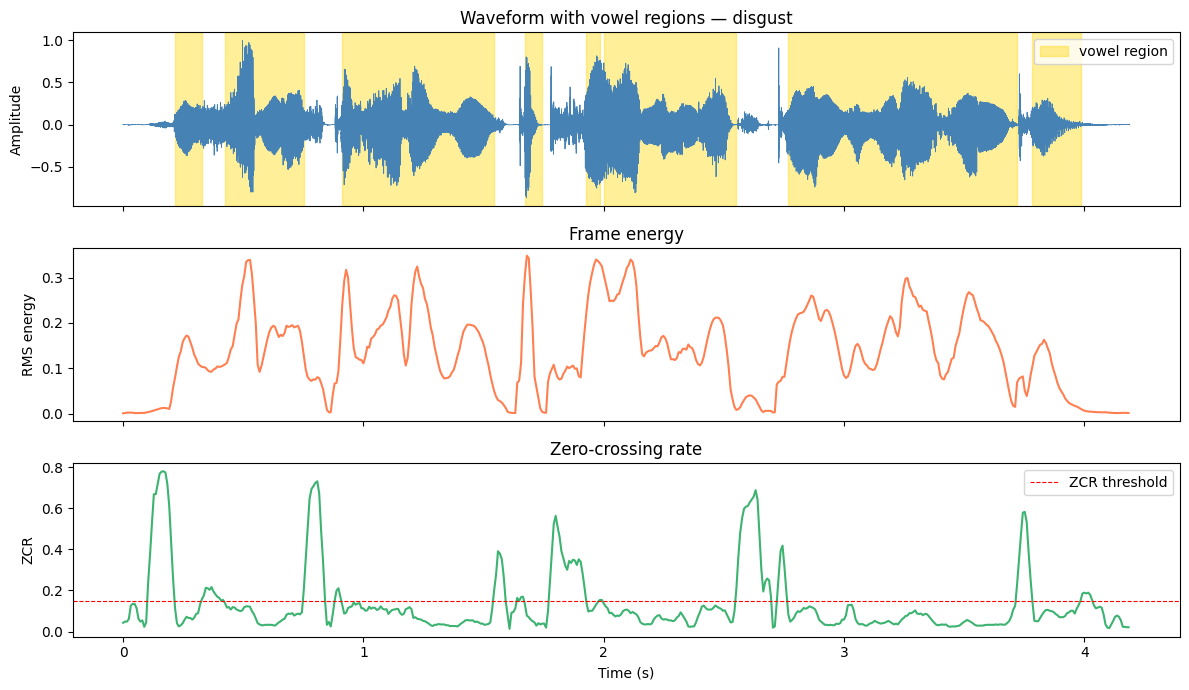


Emotion       Avg vowel count  Avg vowel dur (s)
------------------------------------------------
neutral                  6.81              1.668
fear                     7.45              1.285
boredom                  7.05              2.000
happy                    8.24              1.377
sad                     11.40              2.910
angry                    8.34              1.121
disgust                  8.85              1.922


In [12]:
# ============================================================
# VOWEL REGION DETECTION & FEATURE EXTRACTION
# ============================================================

import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from collections import Counter


# ── 1. Vowel region detector ────────────────────────────────
def detect_vowel_regions(signal, sr=16000,
                          frame_len=512, hop_len=128,
                          energy_threshold=0.02,
                          zcr_threshold=0.15,
                          min_vowel_dur=0.05):
    """
    Detect vowel-like regions using energy + ZCR.
    
    Vowels: HIGH energy, LOW zero-crossing rate
    Consonants/silence: low energy OR high ZCR
    
    Returns list of (start_sample, end_sample) tuples.
    """
    # Frame-level energy (RMS)
    rms = librosa.feature.rms(y=signal, frame_length=frame_len,
                               hop_length=hop_len)[0]
    
    # Frame-level zero-crossing rate
    zcr = librosa.feature.zero_crossing_rate(signal, frame_length=frame_len,
                                              hop_length=hop_len)[0]
    
    # Normalize energy to [0, 1] for threshold robustness
    rms_norm = rms / (np.max(rms) + 1e-8)
    
    # Vowel mask: high energy AND low ZCR
    vowel_mask = (rms_norm > energy_threshold) & (zcr < zcr_threshold)
    
    # Convert frame mask to sample-level segments
    min_frames = int(min_vowel_dur * sr / hop_len)
    regions = []
    in_vowel = False
    start_frame = 0

    for i, is_vowel in enumerate(vowel_mask):
        if is_vowel and not in_vowel:
            start_frame = i
            in_vowel = True
        elif not is_vowel and in_vowel:
            if (i - start_frame) >= min_frames:
                start_samp = start_frame * hop_len
                end_samp = min(i * hop_len, len(signal))
                regions.append((start_samp, end_samp))
            in_vowel = False

    if in_vowel and (len(vowel_mask) - start_frame) >= min_frames:
        regions.append((start_frame * hop_len,
                        min(len(vowel_mask) * hop_len, len(signal))))

    return regions


# ── 2. Feature extraction from vowel regions ────────────────
def extract_formant_approx(segment, sr=16000, n_lpc=10):
    """
    Approximate F1/F2 via LPC pole frequencies.
    LPC is computationally light and well-suited for short vowel segments.
    """
    if len(segment) < n_lpc + 1:
        return 0.0, 0.0

    # Pre-emphasis
    pre = np.append(segment[0], segment[1:] - 0.97 * segment[:-1])

    try:
        # LPC coefficients
        lpc_coeffs = librosa.lpc(pre, order=n_lpc)
        
        # Roots of LPC polynomial → pole frequencies
        roots = np.roots(lpc_coeffs)
        roots = roots[np.imag(roots) >= 0]  # keep upper half-plane
        
        angles = np.angle(roots)
        freqs = angles * (sr / (2 * np.pi))
        freqs = np.sort(freqs[freqs > 50])  # ignore DC
        
        f1 = freqs[0] if len(freqs) > 0 else 0.0
        f2 = freqs[1] if len(freqs) > 1 else 0.0
        return f1, f2
    except Exception:
        return 0.0, 0.0


def extract_vowel_features(signal, sr=16000, n_mfcc=26, max_regions=5):
    """
    For each detected vowel region:
      - Extract MFCCs (mean across frames in region)
      - Approximate F1, F2 formants via LPC
    
    Aggregate across regions → fixed-size feature vector.
    """
    regions = detect_vowel_regions(signal, sr)
    
    region_features = []
    for (start, end) in regions[:max_regions]:
        seg = signal[start:end]
        if len(seg) < 512:
            continue
        
        # MFCC means over the segment
        mfcc = librosa.feature.mfcc(y=seg, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfcc, axis=1)          # (n_mfcc,)
        mfcc_std  = np.std(mfcc, axis=1)           # (n_mfcc,)
        
        # Formants
        f1, f2 = extract_formant_approx(seg, sr)
        
        # Concat: [mfcc_mean | mfcc_std | f1 | f2]
        feat = np.concatenate([mfcc_mean, mfcc_std, [f1, f2]])
        region_features.append(feat)
    
    feat_dim = 2 * n_mfcc + 2  # per-region feature size
    
    if len(region_features) == 0:
        # Silence / no vowels detected → zeros
        return np.zeros(max_regions * feat_dim)
    
    # Pad or trim to max_regions
    while len(region_features) < max_regions:
        region_features.append(np.zeros(feat_dim))
    region_features = region_features[:max_regions]
    
    return np.concatenate(region_features)   # (max_regions * feat_dim,)


# ── 3. Build vowel feature matrix from X_audio ──────────────
print("Extracting vowel-region features...")

X_vowel = []
for signal in X_audio:
    feat = extract_vowel_features(signal)
    X_vowel.append(feat)

X_vowel = np.array(X_vowel)
print(f"Vowel feature shape: {X_vowel.shape}")
# → (n_samples, max_regions * (2*n_mfcc + 2))


# ── 4. Fused feature matrix ──────────────────────────────────
# X_flat is your existing full-signal flattened MFCC array
X_fused = np.concatenate([X_flat, X_vowel], axis=1)
print(f"Fused feature shape: {X_fused.shape}")


# ── 5. Train & compare three SVMs ───────────────────────────
def run_svm(X, y_enc, label="Model"):
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X)
    
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sc, y_enc, test_size=0.2, random_state=42
    )
    svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
    svm.fit(X_tr, y_tr)
    
    acc = svm.score(X_te, y_te)
    print(f"\n{'='*50}")
    print(f"{label}  —  Accuracy: {acc:.4f}")
    print(classification_report(y_te, svm.predict(X_te),
                                 target_names=le.classes_))
    return acc

acc_full   = run_svm(X_flat,   y_encoded, "Full-signal MFCCs (baseline)")
acc_vowel  = run_svm(X_vowel,  y_encoded, "Vowel-region features only")
acc_fused  = run_svm(X_fused,  y_encoded, "Fused (full + vowel)")

print(f"\n{'='*50}")
print(f"Baseline  : {acc_full:.4f}")
print(f"Vowel only: {acc_vowel:.4f}")
print(f"Fused     : {acc_fused:.4f}")
print(f"Delta (fused vs baseline): {acc_fused - acc_full:+.4f}")


# ── 6. Visualise vowel regions on a sample waveform ─────────
def plot_vowel_regions(file_path, emotion, sr=16000):
    signal, _ = librosa.load(file_path, sr=sr)
    regions    = detect_vowel_regions(signal, sr)
    times      = np.linspace(0, len(signal)/sr, len(signal))

    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

    # Waveform + highlighted vowel spans
    axes[0].plot(times, signal, color='steelblue', lw=0.6)
    for (s, e) in regions:
        axes[0].axvspan(s/sr, e/sr, color='gold', alpha=0.4, label='vowel region')
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title(f"Waveform with vowel regions — {emotion}")
    handles, labels_ = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend([handles[0]], ["vowel region"], loc='upper right')

    # RMS energy
    rms = librosa.feature.rms(y=signal, frame_length=512, hop_length=128)[0]
    t_frames = librosa.frames_to_time(np.arange(len(rms)),
                                       sr=sr, hop_length=128)
    axes[1].plot(t_frames, rms, color='coral')
    axes[1].set_ylabel("RMS energy")
    axes[1].set_title("Frame energy")

    # ZCR
    zcr = librosa.feature.zero_crossing_rate(signal, frame_length=512,
                                              hop_length=128)[0]
    axes[2].plot(t_frames, zcr, color='mediumseagreen')
    axes[2].axhline(0.15, color='red', ls='--', lw=0.8, label='ZCR threshold')
    axes[2].set_ylabel("ZCR")
    axes[2].set_title("Zero-crossing rate")
    axes[2].set_xlabel("Time (s)")
    axes[2].legend(loc='upper right')

    plt.tight_layout()
    plt.show()


# Plot one sample per emotion
for emotion, file_path in sample_files.items():
    plot_vowel_regions(file_path, emotion)


# ── 7. Vowel count & duration stats per emotion ─────────────
vowel_stats = {e: {'count': [], 'duration': []} for e in df["emotion"].unique()}

for _, row in df.iterrows():
    fp = os.path.join(emodb_path, row["file"])
    signal, sr = librosa.load(fp, sr=16000)
    regions = detect_vowel_regions(signal, sr)
    
    vowel_stats[row["emotion"]]['count'].append(len(regions))
    total_dur = sum((e - s) for s, e in regions) / sr
    vowel_stats[row["emotion"]]['duration'].append(total_dur)

# Summary table
print(f"\n{'Emotion':<12} {'Avg vowel count':>16} {'Avg vowel dur (s)':>18}")
print("-" * 48)
for emotion, stats in vowel_stats.items():
    avg_cnt = np.mean(stats['count'])
    avg_dur = np.mean(stats['duration'])
    print(f"{emotion:<12} {avg_cnt:>16.2f} {avg_dur:>18.3f}")

### VOP and VEP:

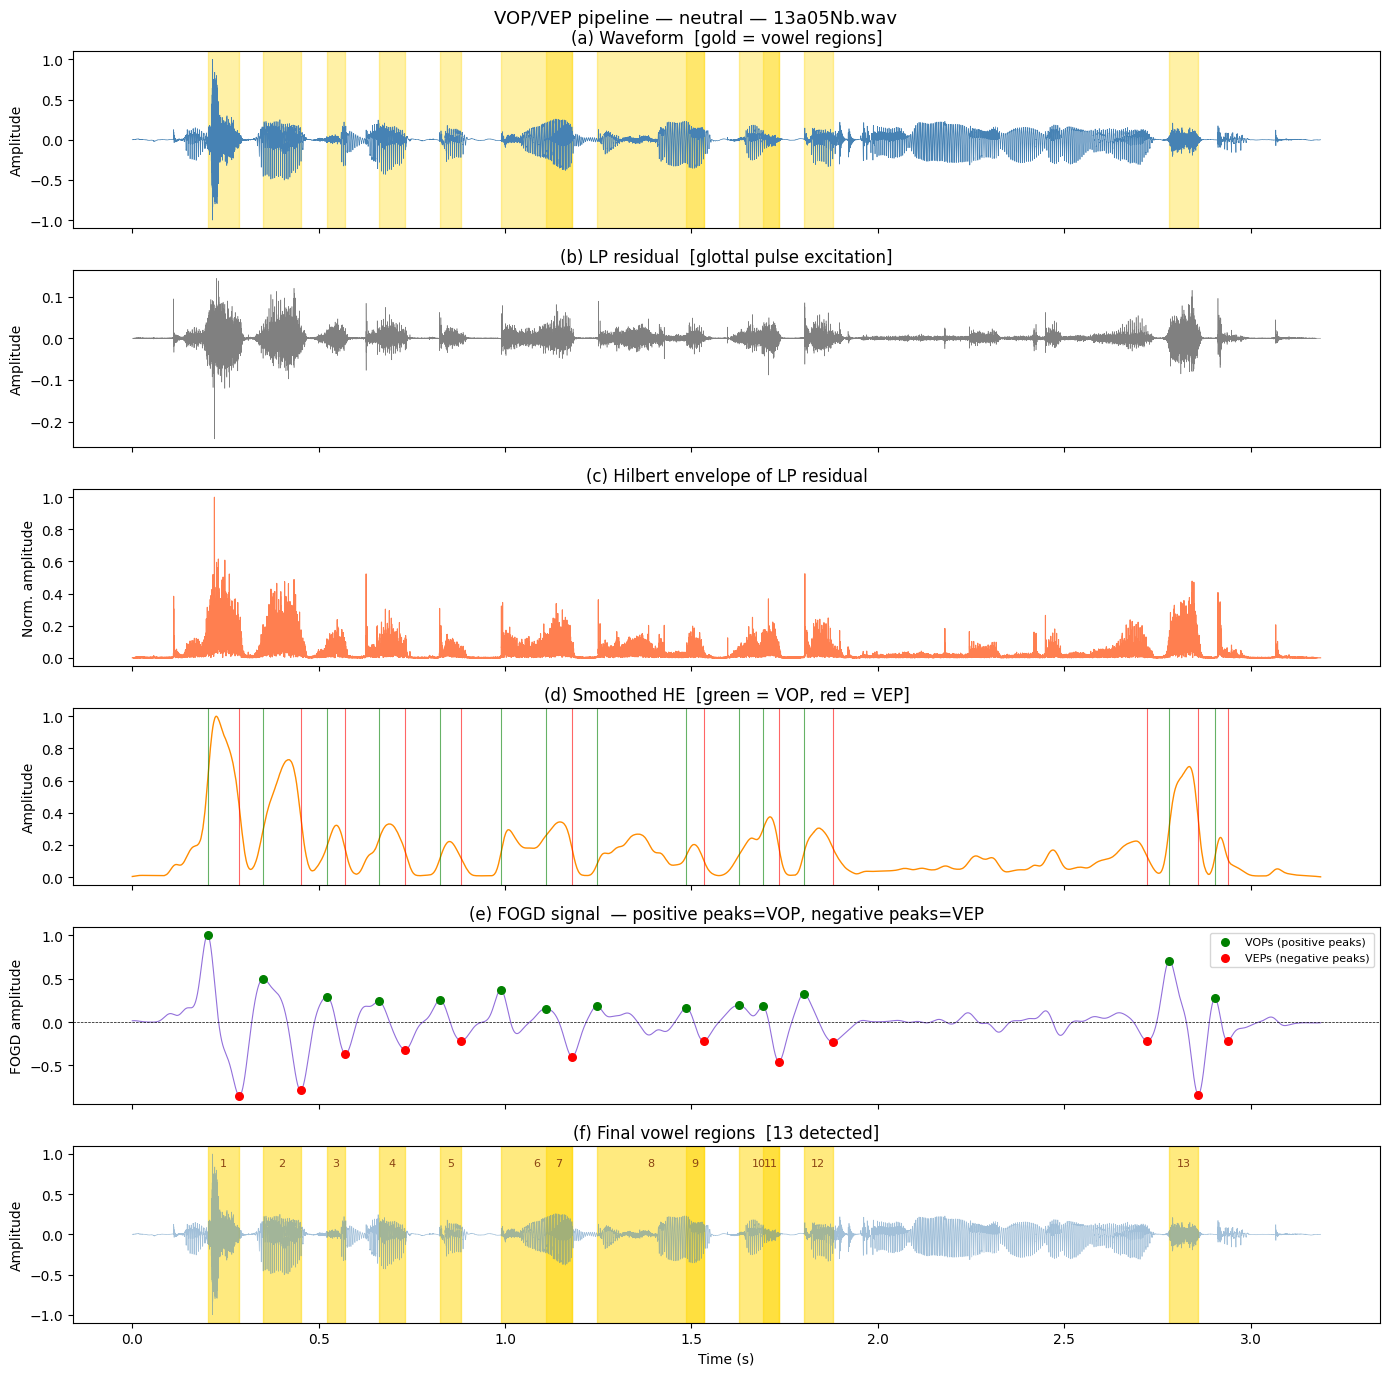


neutral — 13a05Nb.wav
  VOPs detected : 14
  VEPs detected : 12
  Paired regions: 13
    [1] 0.202s – 0.287s  (85 ms)
    [2] 0.351s – 0.451s  (100 ms)
    [3] 0.521s – 0.572s  (51 ms)
    [4] 0.661s – 0.732s  (71 ms)
    [5] 0.825s – 0.882s  (57 ms)
    [6] 0.988s – 1.180s  (192 ms)
    [7] 1.110s – 1.180s  (70 ms)
    [8] 1.246s – 1.533s  (286 ms)
    [9] 1.486s – 1.533s  (47 ms)
    [10] 1.626s – 1.734s  (108 ms)
    [11] 1.691s – 1.734s  (44 ms)
    [12] 1.802s – 1.879s  (78 ms)
    [13] 2.782s – 2.860s  (78 ms)


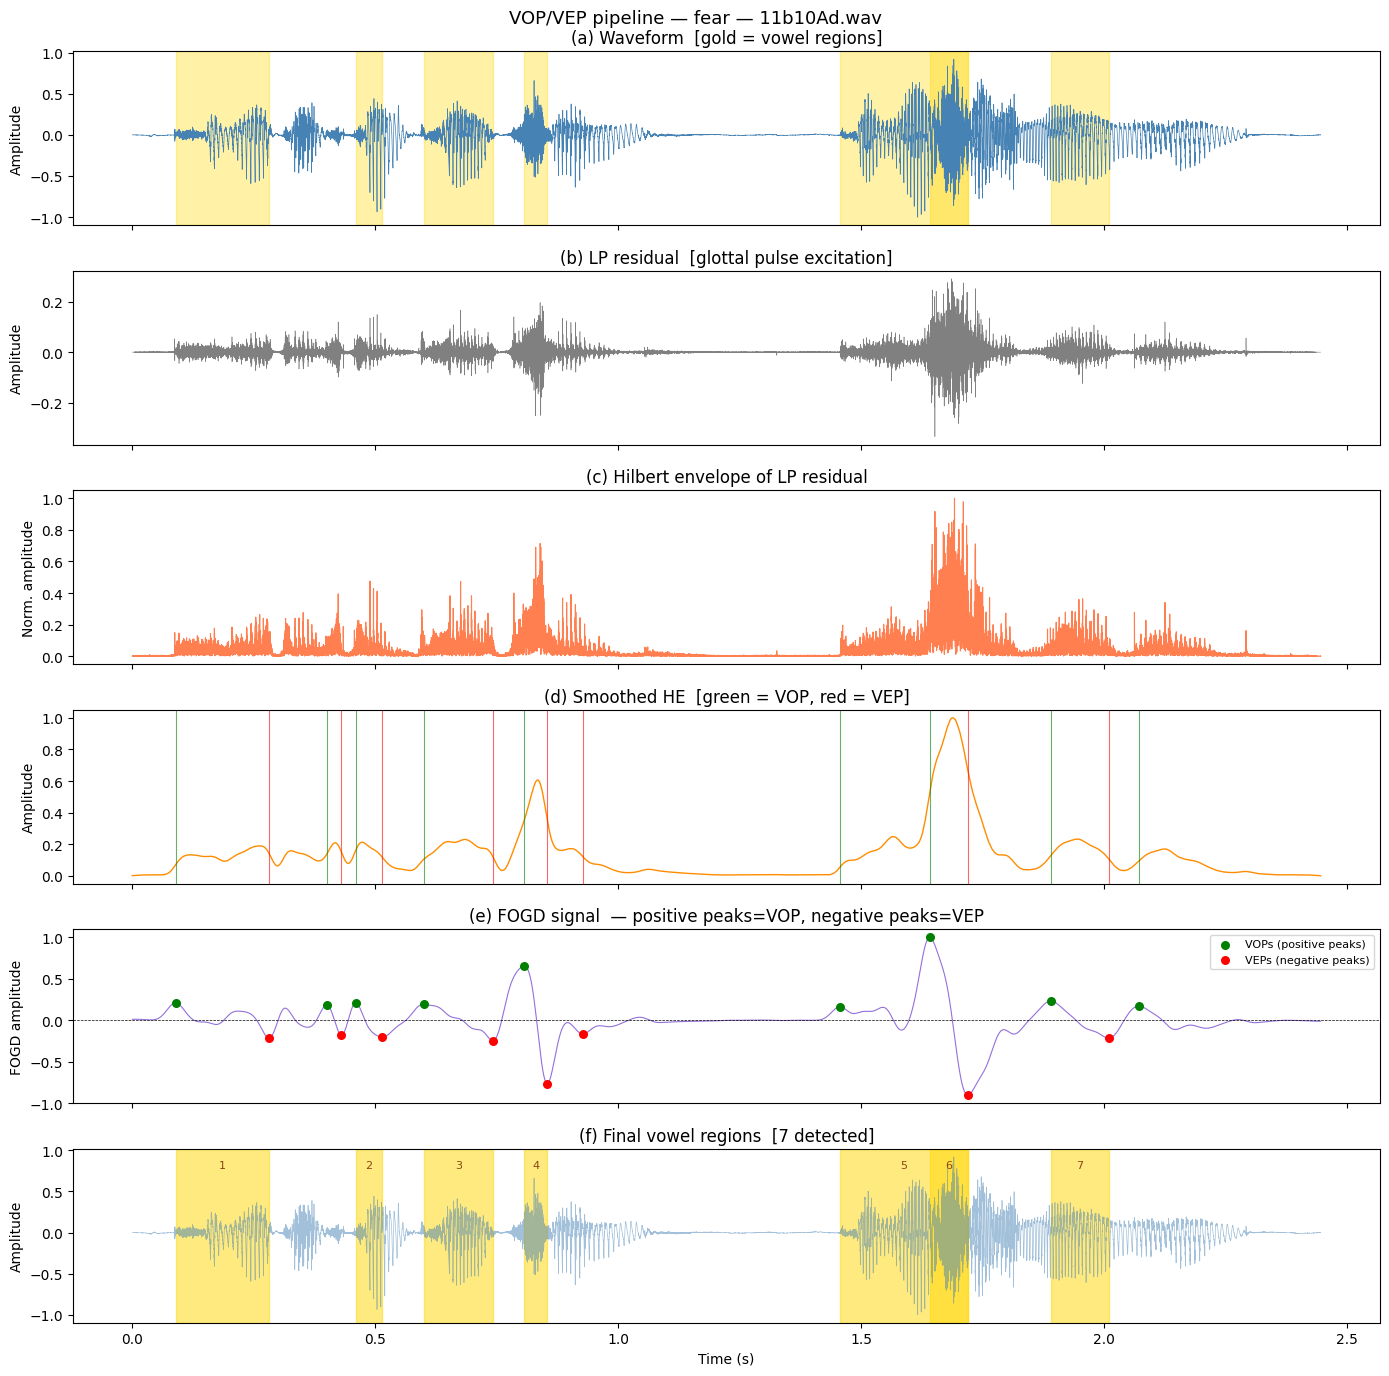


fear — 11b10Ad.wav
  VOPs detected : 9
  VEPs detected : 8
  Paired regions: 7
    [1] 0.089s – 0.281s  (192 ms)
    [2] 0.460s – 0.514s  (54 ms)
    [3] 0.600s – 0.742s  (142 ms)
    [4] 0.806s – 0.854s  (48 ms)
    [5] 1.456s – 1.720s  (264 ms)
    [6] 1.641s – 1.720s  (79 ms)
    [7] 1.890s – 2.009s  (119 ms)


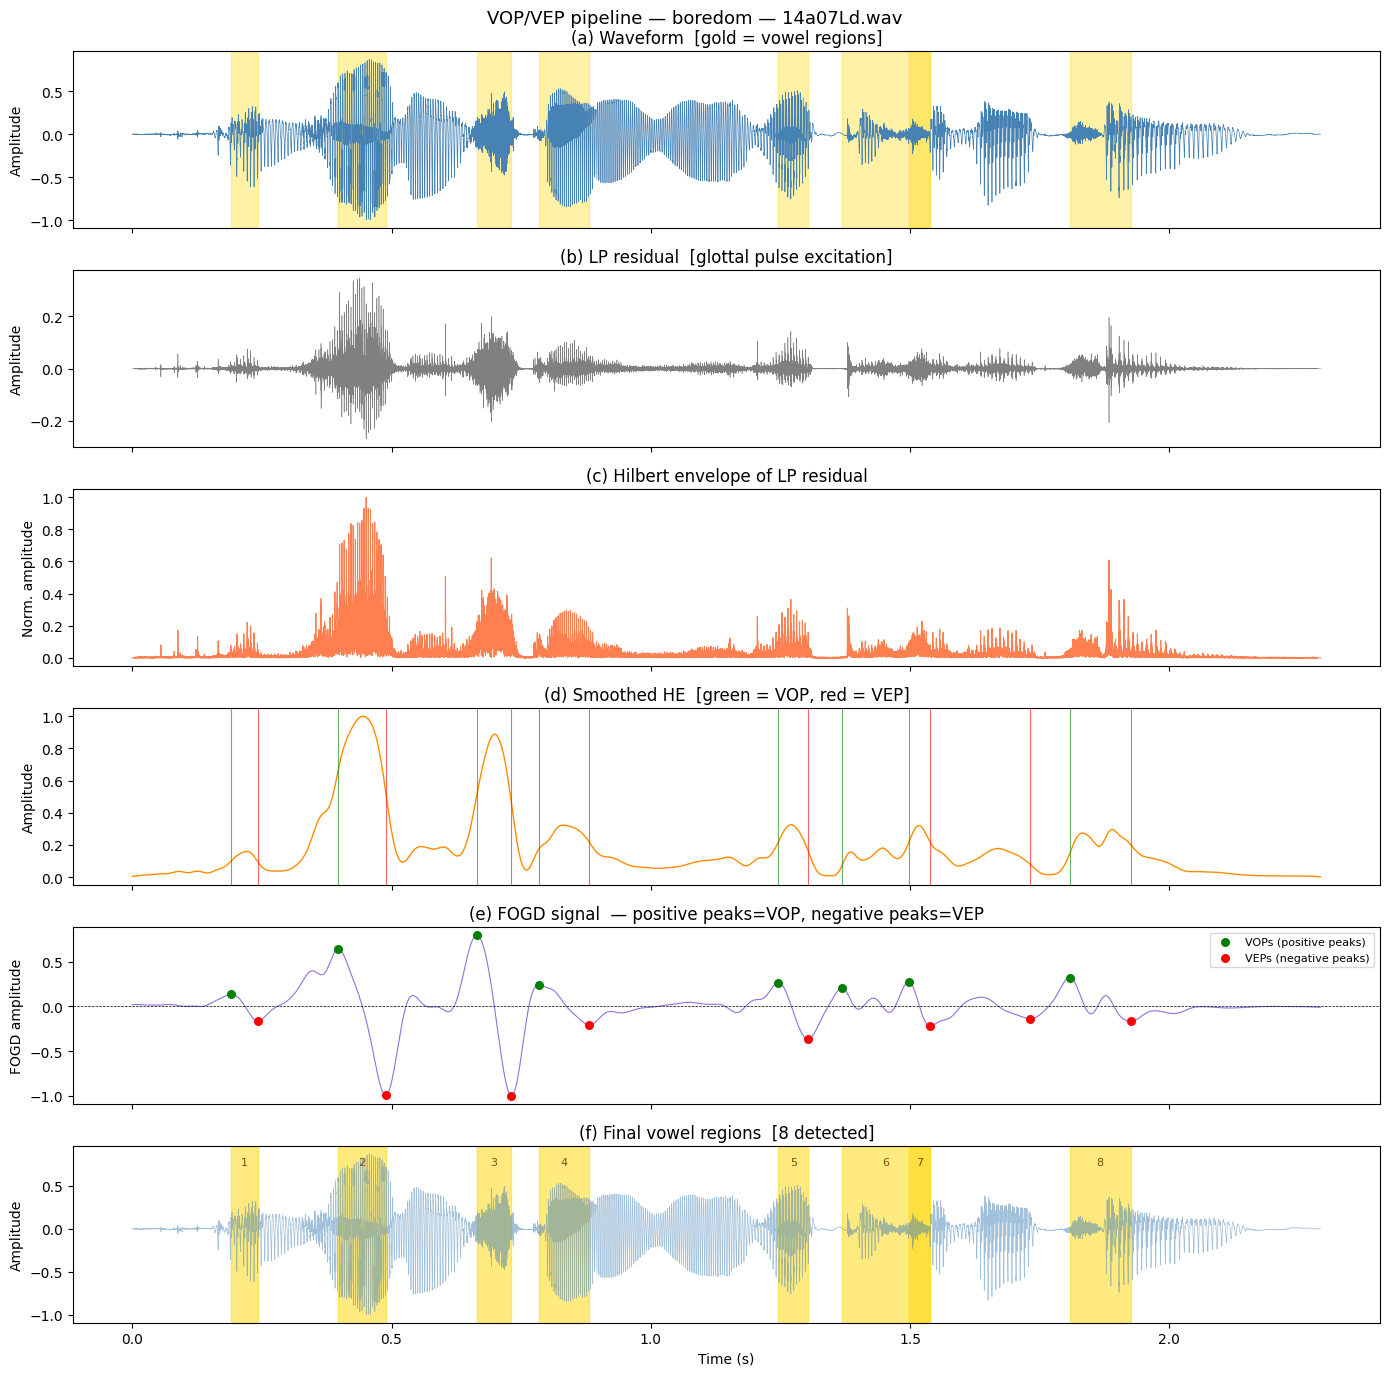


boredom — 14a07Ld.wav
  VOPs detected : 8
  VEPs detected : 8
  Paired regions: 8
    [1] 0.191s – 0.242s  (51 ms)
    [2] 0.397s – 0.489s  (91 ms)
    [3] 0.664s – 0.731s  (67 ms)
    [4] 0.784s – 0.882s  (98 ms)
    [5] 1.246s – 1.303s  (57 ms)
    [6] 1.369s – 1.539s  (171 ms)
    [7] 1.497s – 1.539s  (42 ms)
    [8] 1.808s – 1.926s  (118 ms)


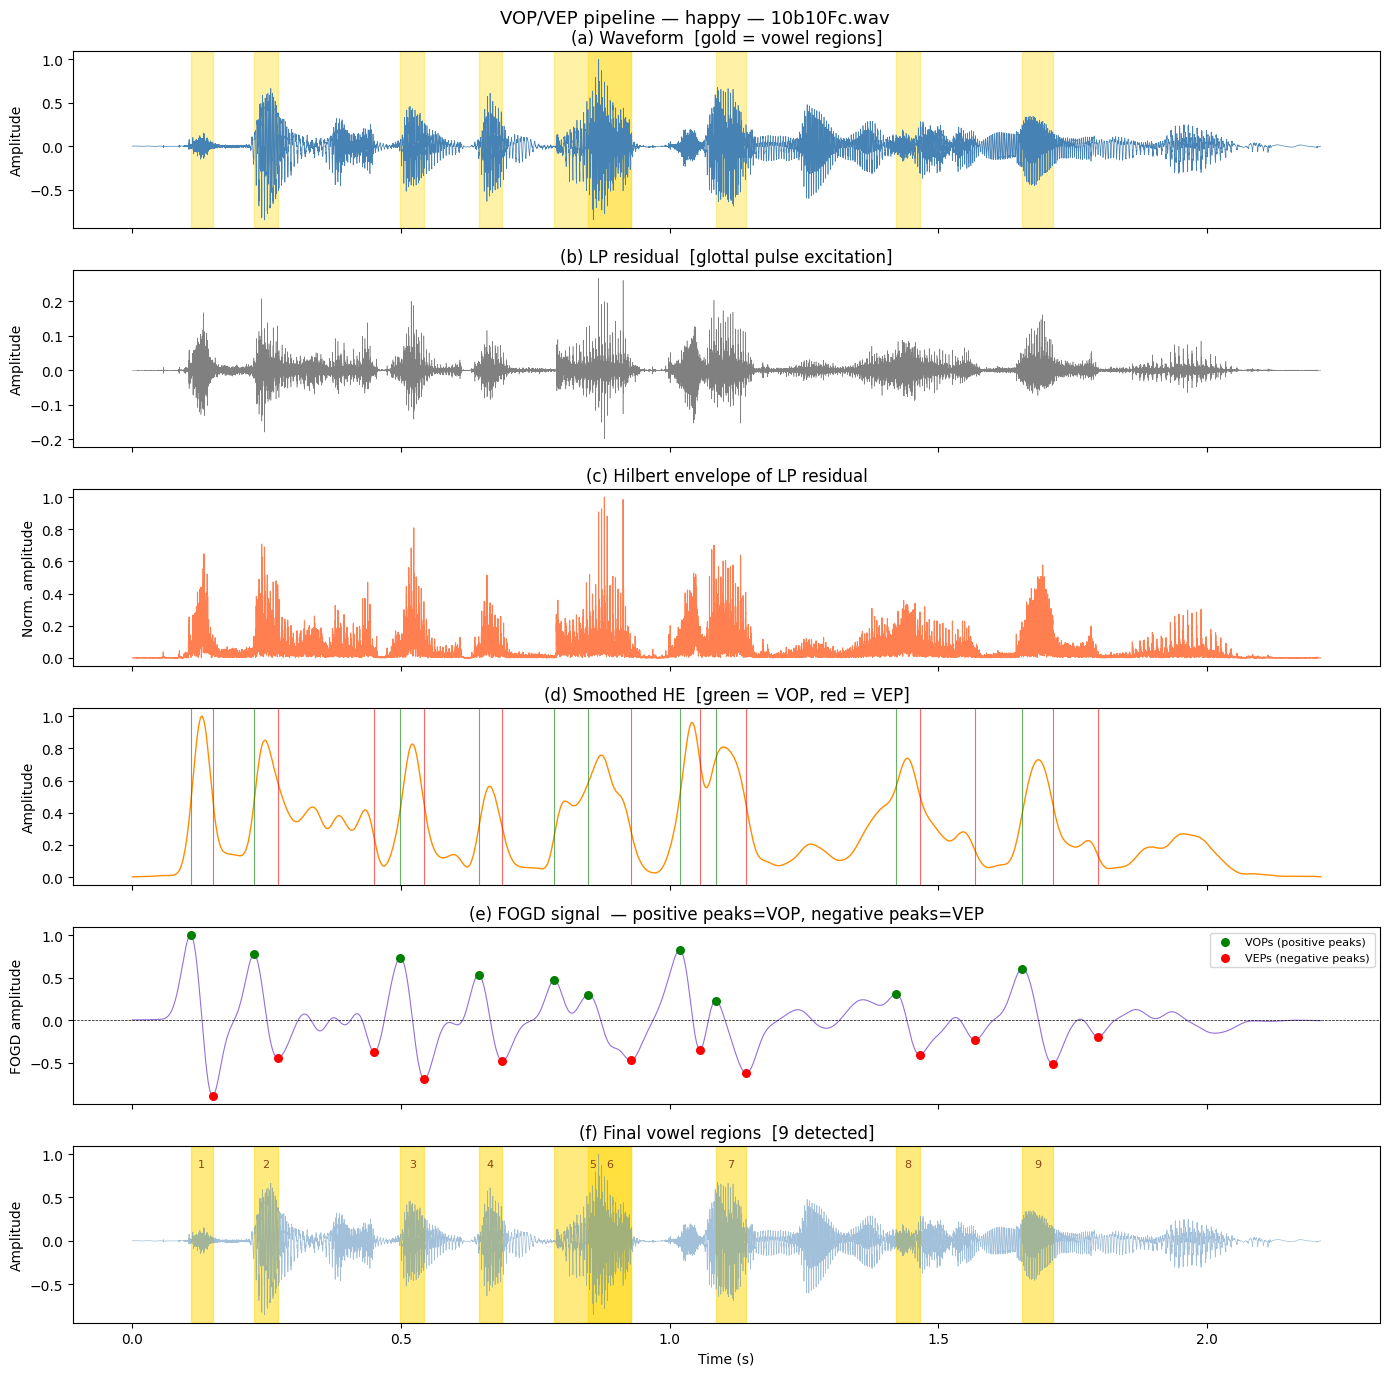


happy — 10b10Fc.wav
  VOPs detected : 10
  VEPs detected : 12
  Paired regions: 9
    [1] 0.108s – 0.149s  (41 ms)
    [2] 0.226s – 0.271s  (45 ms)
    [3] 0.499s – 0.543s  (45 ms)
    [4] 0.644s – 0.689s  (45 ms)
    [5] 0.785s – 0.927s  (142 ms)
    [6] 0.849s – 0.927s  (78 ms)
    [7] 1.086s – 1.143s  (57 ms)
    [8] 1.421s – 1.465s  (44 ms)
    [9] 1.657s – 1.713s  (56 ms)


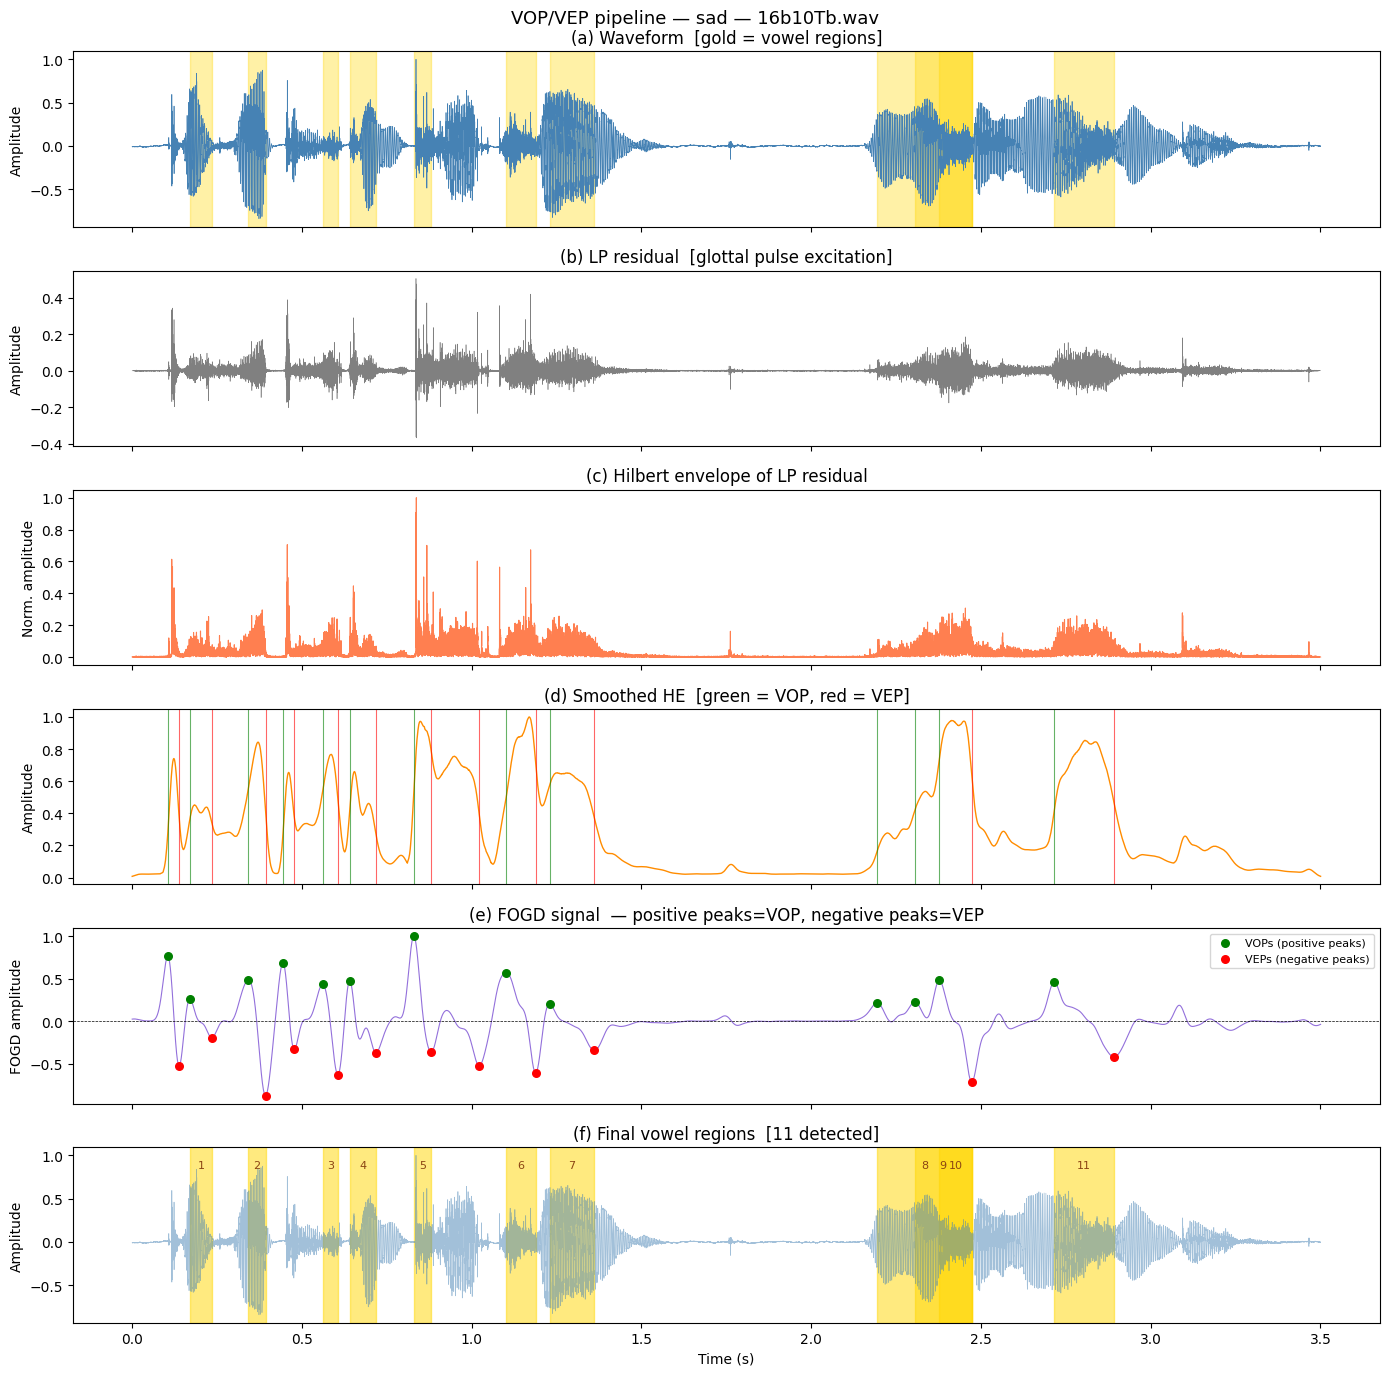


sad — 16b10Tb.wav
  VOPs detected : 13
  VEPs detected : 12
  Paired regions: 11
    [1] 0.170s – 0.234s  (64 ms)
    [2] 0.342s – 0.393s  (50 ms)
    [3] 0.561s – 0.606s  (45 ms)
    [4] 0.641s – 0.718s  (78 ms)
    [5] 0.830s – 0.881s  (51 ms)
    [6] 1.101s – 1.188s  (87 ms)
    [7] 1.230s – 1.361s  (132 ms)
    [8] 2.194s – 2.473s  (279 ms)
    [9] 2.305s – 2.473s  (168 ms)
    [10] 2.378s – 2.473s  (96 ms)
    [11] 2.716s – 2.892s  (176 ms)


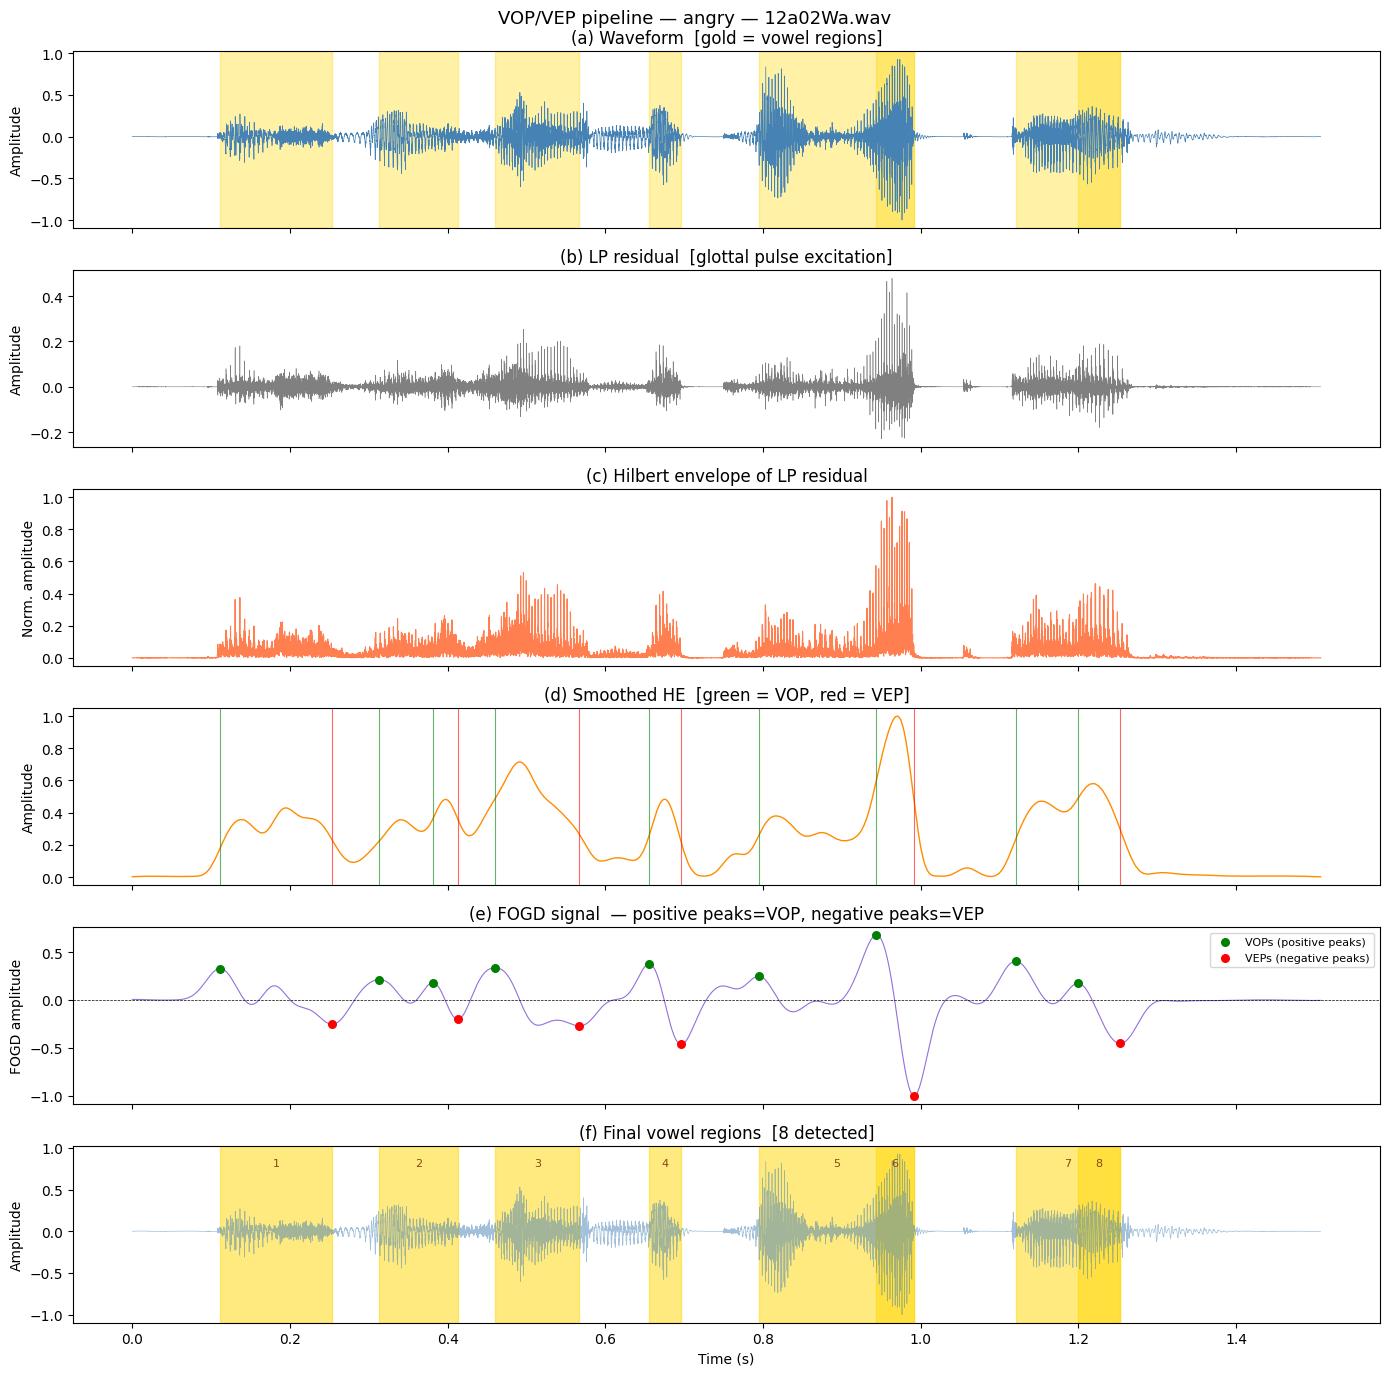


angry — 12a02Wa.wav
  VOPs detected : 9
  VEPs detected : 6
  Paired regions: 8
    [1] 0.111s – 0.254s  (142 ms)
    [2] 0.314s – 0.413s  (99 ms)
    [3] 0.460s – 0.567s  (107 ms)
    [4] 0.656s – 0.696s  (41 ms)
    [5] 0.794s – 0.992s  (197 ms)
    [6] 0.944s – 0.992s  (48 ms)
    [7] 1.121s – 1.253s  (133 ms)
    [8] 1.200s – 1.253s  (54 ms)


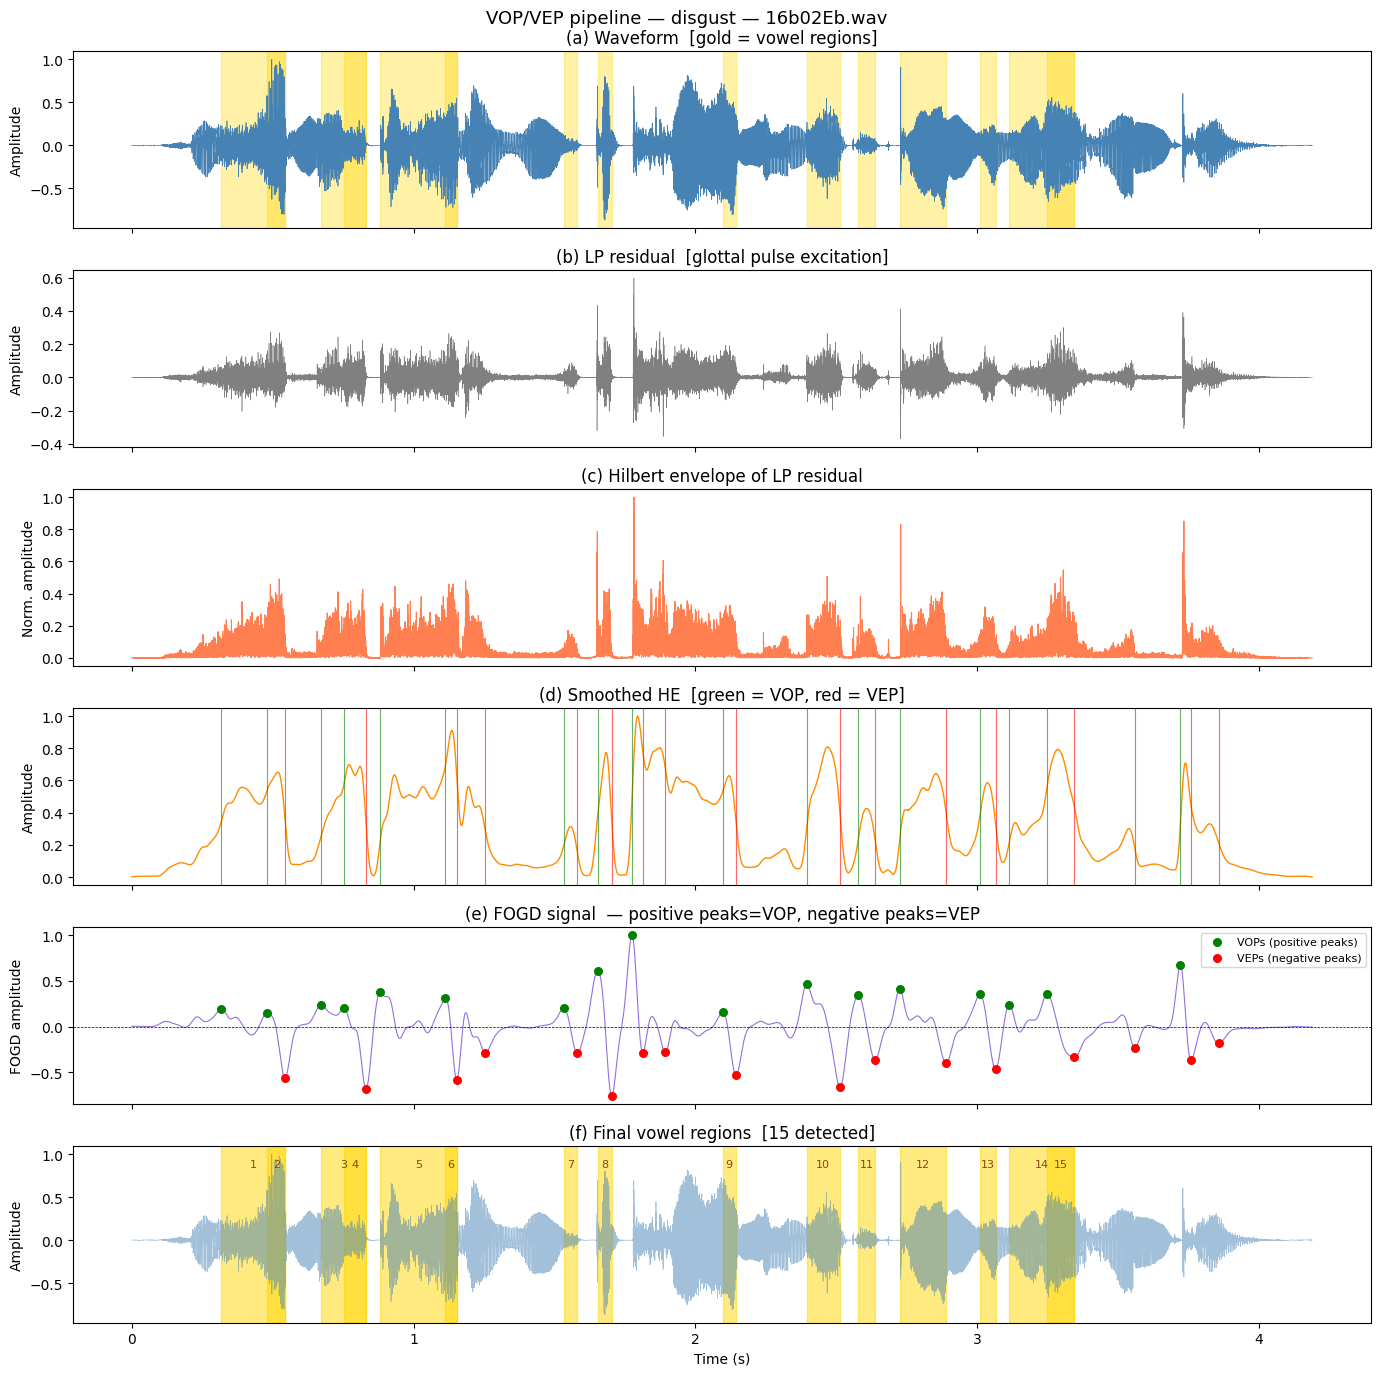


disgust — 16b02Eb.wav
  VOPs detected : 17
  VEPs detected : 17
  Paired regions: 15
    [1] 0.318s – 0.544s  (226 ms)
    [2] 0.481s – 0.544s  (62 ms)
    [3] 0.672s – 0.831s  (159 ms)
    [4] 0.752s – 0.831s  (79 ms)
    [5] 0.882s – 1.153s  (271 ms)
    [6] 1.113s – 1.153s  (40 ms)
    [7] 1.532s – 1.581s  (49 ms)
    [8] 1.653s – 1.703s  (50 ms)
    [9] 2.096s – 2.144s  (48 ms)
    [10] 2.395s – 2.513s  (118 ms)
    [11] 2.578s – 2.638s  (60 ms)
    [12] 2.724s – 2.890s  (165 ms)
    [13] 3.009s – 3.065s  (55 ms)
    [14] 3.114s – 3.345s  (231 ms)
    [15] 3.248s – 3.345s  (96 ms)

Extracting VOP/VEP vowel features for all augmented samples...


/home/nida/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1367
  warnings.warn(
/home/nida/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1599
  warnings.warn(
/home/nida/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=809
  warnings.warn(
/home/nida/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1136
  warnings.warn(
/home/nida/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=915
  warnings.warn(
/home/nida/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1099
  warnings.warn(
/home/nida/.local/lib/py

VOP/VEP vowel feature shape: (910, 270)

VOP/VEP vowel features only  —  Accuracy: 0.7198
              precision    recall  f1-score   support

       angry       0.72      0.84      0.78        25
     boredom       0.77      0.64      0.70        36
     disgust       0.88      0.88      0.88        24
        fear       0.68      0.62      0.65        24
       happy       0.78      0.61      0.68        23
     neutral       0.46      0.59      0.52        27
         sad       0.88      0.91      0.89        23

    accuracy                           0.72       182
   macro avg       0.74      0.73      0.73       182
weighted avg       0.73      0.72      0.72       182


Fused (full MFCC + VOP/VEP)  —  Accuracy: 0.8462
              precision    recall  f1-score   support

       angry       0.86      0.96      0.91        25
     boredom       0.82      0.78      0.80        36
     disgust       0.95      0.88      0.91        24
        fear       0.85      0.92      0.88   

In [13]:
# ============================================================
# VOP / VEP DETECTION  — EmoDB pipeline extension
# Replaces the earlier RMS+ZCR+flatness detector entirely.
# Method: LPC residual → Hilbert envelope → smooth → FOGD
#         positive peaks = VOPs (onsets), negative peaks = VEPs (offsets)
# ============================================================

import numpy as np
import librosa
from scipy.signal import lfilter, hilbert, find_peaks
from scipy.signal.windows import hamming, gaussian


# ── 1. LP Residual ───────────────────────────────────────────
def compute_lp_residual(signal, sr, lpc_order=10,
                         frame_ms=20, hop_ms=10):
    """
    Frame the signal, apply LPC per frame, collect inverse-filter output.
    
    LPC models the vocal tract as an all-pole filter A(z).
    Filtering the speech through A(z) removes the vocal tract,
    leaving behind the excitation (glottal pulses + noise) = LP residual.
    
    This is the key step: the residual has sharp peaks at glottal closure
    instants (GCIs), which is exactly what drives VOP/VEP detection.
    """
    frame_len = int(frame_ms / 1000 * sr)
    hop_len   = int(hop_ms  / 1000 * sr)
    
    # Pre-emphasis — boosts high frequencies, improves LPC conditioning
    pre = np.append(signal[0], signal[1:] - 0.97 * signal[:-1])
    
    residual = np.zeros_like(pre)
    win      = hamming(frame_len)
    
    for start in range(0, len(pre) - frame_len, hop_len):
        frame    = pre[start : start + frame_len] * win
        lpc_coef = librosa.lpc(frame, order=lpc_order)   # returns [1, a1, a2, ...]
        
        # lfilter(b, a, x): b=LPC coeffs (analysis filter), a=[1]
        frame_residual = lfilter(lpc_coef, [1.0], frame)
        
        # Overlap-add accumulation
        residual[start : start + frame_len] += frame_residual
    
    return residual


# ── 2. Hilbert Envelope ──────────────────────────────────────
def hilbert_envelope(residual):
    """
    |H{residual}| gives the instantaneous amplitude (envelope).
    
    The Hilbert transform produces an analytic signal whose magnitude
    traces the 'outline' of the waveform — peaks at each glottal pulse,
    valleys between pulses. This is what we smooth and differentiate.
    """
    he = np.abs(hilbert(residual))
    he /= (np.max(he) + 1e-8)   # normalize to [0,1]
    return he


# ── 3. Smoothing ─────────────────────────────────────────────
def smooth_envelope(he, sr, window_ms=50):
    """
    Convolve the Hilbert envelope with a normalized Hamming window.
    
    50ms is long enough to bridge individual glottal pulses (which occur
    at ~8-14ms intervals for typical F0), but short enough to track the
    syllable-level energy contour that drives VOP/VEP detection.
    """
    win_len = int(window_ms / 1000 * sr)
    if win_len % 2 == 0:
        win_len += 1
    win = hamming(win_len)
    win /= win.sum()
    
    smoothed = np.convolve(he, win, mode='same')
    
    # Restore amplitude scale after convolution
    smoothed *= (np.max(he) / (np.max(smoothed) + 1e-8))
    return smoothed


# ── 4. FOGD (First-Order Gaussian Derivative) ────────────────
def compute_fogd(smoothed, sr, kernel_ms=80, std_fraction=6):
    """
    Convolve the smoothed envelope with the derivative of a Gaussian.
    
    Why Gaussian derivative and not plain np.diff?
    ─────────────────────────────────────────────
    np.diff is noisy — it amplifies high-frequency jitter in the envelope.
    The Gaussian derivative is a smoothed differentiator:
      • The Gaussian part suppresses noise
      • The derivative part detects slope changes
    
    The result: a signal whose
      • positive peaks  = rising slopes in smoothed_he  = VOWEL ONSETS  (VOPs)
      • negative peaks  = falling slopes in smoothed_he = VOWEL OFFSETS (VEPs)
    
    std_fraction: standard deviation = kernel_length / std_fraction
    Larger std_fraction → sharper kernel → detects finer-grained onsets.
    Smaller std_fraction → wider kernel → smoother, misses short vowels.
    """
    kernel_len = int(kernel_ms / 1000 * sr)
    if kernel_len % 2 == 0:
        kernel_len += 1
    std = kernel_len / std_fraction
    
    # Gaussian kernel then differentiate
    half    = kernel_len // 2
    x       = np.arange(-half, half + 1)
    gauss   = np.exp(-(x ** 2) / (2 * std ** 2))
    fogd_k  = np.diff(gauss)                    # length = kernel_len
    
    fogd_out = np.convolve(smoothed, fogd_k, mode='same')
    fogd_out /= (np.max(np.abs(fogd_out)) + 1e-8)
    return fogd_out


# ── 5. VOP and VEP peak picking ──────────────────────────────
def pick_vop_vep(fogd_signal, sr,
                  min_gap_ms      = 50,    # minimum spacing between VOPs or VEPs
                  slope_thresh    = 0.5,   # fraction of mean |slope| to accept
                  prominence_frac = 0.08): # min prominence as fraction of max
    """
    VOPs  = positive peaks of the FOGD signal (rising edge of HE)
    VEPs  = negative peaks of the FOGD signal (falling edge of HE)
    
    Two-stage filtering (mirrors your reference code):
      1. Slope-sum threshold  — removes weak, spurious peaks
      2. Proximity pruning    — keeps only the strongest in each cluster
    
    Parameters tuned for EmoDB (16 kHz, read speech, 3-10 second utterances).
    """
    min_gap_samples = int(min_gap_ms / 1000 * sr)
    
    # ── positive peaks → VOPs ────────────────────────────────
    vop_raw, vop_props = find_peaks(
        fogd_signal,
        distance   = min_gap_samples,
        prominence = prominence_frac * np.max(fogd_signal)
    )
    
    # Slope-sum threshold on raw VOP candidates
    slope_win = int(0.01 * sr)
    vop_slopes = np.array([
        np.sum(fogd_signal[max(0, n - slope_win) : n + slope_win])
        for n in vop_raw
    ])
    if len(vop_slopes) > 0:
        slope_thr  = slope_thresh * np.mean(np.abs(vop_slopes))
        vop_keep   = vop_raw[vop_slopes >= slope_thr]
    else:
        vop_keep = vop_raw
    
    # ── negative peaks → VEPs  (flip sign, find peaks) ───────
    vep_raw, _ = find_peaks(
        -fogd_signal,
        distance   = min_gap_samples,
        prominence = prominence_frac * np.max(-fogd_signal)
    )
    
    vep_slopes = np.array([
        np.sum(-fogd_signal[max(0, n - slope_win) : n + slope_win])
        for n in vep_raw
    ])
    if len(vep_slopes) > 0:
        slope_thr  = slope_thresh * np.mean(np.abs(vep_slopes))
        vep_keep   = vep_raw[vep_slopes >= slope_thr]
    else:
        vep_keep = vep_raw
    
    return vop_keep, vep_keep


# ── 6. Pair VOPs → VEPs to form vowel regions ────────────────
def pair_vop_vep(vops, veps, signal_len,
                  min_dur_ms=40, max_dur_ms=400, sr=16000):
    """
    Each VOP is paired with the nearest VEP that comes AFTER it.
    
    Rules (linguistics-motivated for German):
    • min_dur_ms = 40ms  — German short vowels (/ɪ/, /ʊ/) are rarely shorter
    • max_dur_ms = 400ms — Long stressed vowels + umlaut lengthening cap
    
    A VOP with no following VEP before the next VOP is discarded
    (probably a false onset from a voiced consonant like /m/, /n/, /l/).
    """
    min_dur = int(min_dur_ms / 1000 * sr)
    max_dur = int(max_dur_ms / 1000 * sr)
    
    regions = []
    for vop in vops:
        # VEPs that follow this VOP
        candidates = veps[veps > vop]
        if len(candidates) == 0:
            continue
        
        vep = candidates[0]           # nearest following VEP
        dur = vep - vop
        
        if min_dur <= dur <= max_dur:
            regions.append((int(vop), int(vep)))
    
    return regions


# ── 7. Full pipeline wrapper ──────────────────────────────────
def detect_vowel_regions_vop_vep(signal, sr=16000,
                                   lpc_order    = 10,
                                   smooth_ms    = 50,
                                   kernel_ms    = 80,
                                   min_gap_ms   = 50,
                                   min_dur_ms   = 40,
                                   max_dur_ms   = 400,
                                   return_intermediates = False):
    """
    Full VOP/VEP-based vowel region detector.
    Drop-in replacement for detect_german_vowel_regions().
    
    Returns
    ───────
    regions : list of (start_sample, end_sample)
    
    If return_intermediates=True, also returns dict with all
    intermediate signals (for plotting / debugging).
    """
    residual = compute_lp_residual(signal, sr, lpc_order=lpc_order)
    he       = hilbert_envelope(residual)
    smoothed = smooth_envelope(he, sr, window_ms=smooth_ms)
    fogd     = compute_fogd(smoothed, sr, kernel_ms=kernel_ms)
    
    vops, veps = pick_vop_vep(fogd, sr, min_gap_ms=min_gap_ms)
    regions    = pair_vop_vep(vops, veps, len(signal),
                               min_dur_ms=min_dur_ms,
                               max_dur_ms=max_dur_ms,
                               sr=sr)
    
    if return_intermediates:
        return regions, {
            'residual': residual,
            'he'      : he,
            'smoothed': smoothed,
            'fogd'    : fogd,
            'vops'    : vops,
            'veps'    : veps,
        }
    return regions


# ── 8. Diagnostic plot (matches your reference figures) ──────
def plot_vop_vep_pipeline(signal, sr, file_label=""):
    """
    6-panel plot showing every stage of the pipeline.
    """
    import matplotlib.pyplot as plt
    
    regions, inter = detect_vowel_regions_vop_vep(
        signal, sr, return_intermediates=True
    )
    residual = inter['residual']
    he       = inter['he']
    smoothed = inter['smoothed']
    fogd     = inter['fogd']
    vops     = inter['vops']
    veps     = inter['veps']
    
    t = np.arange(len(signal)) / sr
    
    fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)
    title = f"VOP/VEP pipeline — {file_label}"
    fig.suptitle(title, fontsize=13)
    
    # (a) Waveform
    axes[0].plot(t, signal, lw=0.5, color='steelblue')
    for s, e in regions:
        axes[0].axvspan(s/sr, e/sr, color='gold', alpha=0.35)
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title("(a) Waveform  [gold = vowel regions]")
    
    # (b) LP residual
    axes[1].plot(t[:len(residual)], residual, lw=0.4, color='gray')
    axes[1].set_ylabel("Amplitude")
    axes[1].set_title("(b) LP residual  [glottal pulse excitation]")
    
    # (c) Hilbert envelope
    axes[2].plot(t[:len(he)], he, lw=0.8, color='coral')
    axes[2].set_ylabel("Norm. amplitude")
    axes[2].set_title("(c) Hilbert envelope of LP residual")
    
    # (d) Smoothed HE
    axes[3].plot(t[:len(smoothed)], smoothed, lw=1, color='darkorange')
    for vop in vops:
        axes[3].axvline(vop/sr, color='green', lw=0.8, alpha=0.6)
    for vep in veps:
        axes[3].axvline(vep/sr, color='red', lw=0.8, alpha=0.6)
    axes[3].set_ylabel("Amplitude")
    axes[3].set_title("(d) Smoothed HE  [green = VOP, red = VEP]")
    
    # (e) FOGD signal with VOP/VEP peaks
    axes[4].plot(t[:len(fogd)], fogd, lw=0.8, color='mediumpurple')
    axes[4].axhline(0, color='black', lw=0.5, ls='--')
    if len(vops) > 0:
        axes[4].scatter(vops/sr, fogd[vops], color='green', s=30,
                        zorder=5, label='VOPs (positive peaks)')
    if len(veps) > 0:
        axes[4].scatter(veps/sr, fogd[veps], color='red', s=30,
                        zorder=5, label='VEPs (negative peaks)')
    axes[4].set_ylabel("FOGD amplitude")
    axes[4].set_title("(e) FOGD signal  — positive peaks=VOP, negative peaks=VEP")
    axes[4].legend(fontsize=8, loc='upper right')
    
    # (f) Final vowel regions on waveform
    axes[5].plot(t, signal, lw=0.5, color='steelblue', alpha=0.5)
    for i, (s, e) in enumerate(regions):
        axes[5].axvspan(s/sr, e/sr, color='gold', alpha=0.5)
        axes[5].text((s + e) / 2 / sr, np.max(signal) * 0.85,
                     str(i+1), ha='center', fontsize=8, color='saddlebrown')
    axes[5].set_ylabel("Amplitude")
    axes[5].set_xlabel("Time (s)")
    axes[5].set_title(f"(f) Final vowel regions  [{len(regions)} detected]")
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{file_label}")
    print(f"  VOPs detected : {len(vops)}")
    print(f"  VEPs detected : {len(veps)}")
    print(f"  Paired regions: {len(regions)}")
    for i, (s, e) in enumerate(regions):
        print(f"    [{i+1}] {s/sr:.3f}s – {e/sr:.3f}s  ({(e-s)/sr*1000:.0f} ms)")


# ── 9. Plug into the EmoDB feature extraction loop ───────────
#
# Replace extract_vowel_features() calls to use VOP/VEP regions.
# The feature extraction logic (MFCCs per region + LPC formants)
# stays exactly the same — only the region detector changes.

def extract_vowel_features_vop_vep(signal, sr=16000,
                                    n_mfcc=26, max_regions=5):
    """
    Same interface as extract_vowel_features() from before.
    Internally uses VOP/VEP detector instead of RMS+ZCR+flatness.
    """
    regions = detect_vowel_regions_vop_vep(signal, sr)
    
    region_features = []
    for (start, end) in regions[:max_regions]:
        seg = signal[start:end]
        if len(seg) < 512:
            continue
        
        mfcc     = librosa.feature.mfcc(y=seg, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std  = np.std(mfcc, axis=1)
        f1, f2   = extract_formant_approx(seg, sr)   # from earlier code
        
        feat = np.concatenate([mfcc_mean, mfcc_std, [f1, f2]])
        region_features.append(feat)
    
    feat_dim = 2 * n_mfcc + 2
    while len(region_features) < max_regions:
        region_features.append(np.zeros(feat_dim))
    region_features = region_features[:max_regions]
    
    return np.concatenate(region_features)


# ── 10. Test — ONE sample per emotion only ───────────────────
for emotion, file_path in sample_files.items():
    signal_test, _ = librosa.load(file_path, sr=16000)
    plot_vop_vep_pipeline(signal_test, 16000,
                          file_label=f"{emotion} — {os.path.basename(file_path)}")

# ── 11. Build feature matrix WITHOUT plotting ─────────────────
print("\nExtracting VOP/VEP vowel features for all augmented samples...")

X_vowel_vopvep = []
for sig in X_audio:
    feat = extract_vowel_features_vop_vep(sig, sr=16000)
    X_vowel_vopvep.append(feat)

X_vowel_vopvep = np.array(X_vowel_vopvep)
print(f"VOP/VEP vowel feature shape: {X_vowel_vopvep.shape}")

X_fused_vopvep = np.concatenate([X_flat, X_vowel_vopvep], axis=1)

acc_vopvep       = run_svm(X_vowel_vopvep,  y_encoded, "VOP/VEP vowel features only")
acc_fused_vopvep = run_svm(X_fused_vopvep,  y_encoded, "Fused (full MFCC + VOP/VEP)")

print(f"\nComparison summary")
print(f"  Full MFCC baseline  : {acc_full:.4f}")
print(f"  VOP/VEP vowels only : {acc_vopvep:.4f}")
print(f"  Fused VOP/VEP       : {acc_fused_vopvep:.4f}")

In [14]:
# ============================================================
# PITCH SYNCHRONOUS ANALYSIS — EmoDB pipeline extension
# Adds GCI detection → pitch-sync frames → PS-MFCC features
# ============================================================

import numpy as np
import librosa
from scipy.signal import lfilter, hilbert, find_peaks
from scipy.signal.windows import hamming

def safe_n_fft(seg_len, default=2048):
    n = 1
    while n * 2 <= seg_len:
        n *= 2
    return max(n, 64)

# ── 1. GCI Detection via LP Residual peaks ───────────────────
def detect_gcis(signal, sr=16000, lpc_order=10,
                f0_min=60, f0_max=300):
    """
    Glottal Closure Instants from LP residual peak picking.

    Why LP residual for GCIs?
    ─────────────────────────
    The LP residual isolates the excitation source. Each glottal
    closure produces a sharp high-amplitude spike in the residual.
    These spikes ARE the GCIs — we just find their locations.

    f0_min/max → constrains minimum/maximum GCI spacing.
    For EmoDB German speakers: 60–300 Hz covers male + female.
    """
    # Pre-emphasis
    pre = np.append(signal[0], signal[1:] - 0.97 * signal[:-1])

    # Full-signal LPC residual (no framing needed for GCI detection)
    frame_len = int(0.02 * sr)
    hop_len   = int(0.005 * sr)
    residual  = np.zeros_like(pre)
    win       = hamming(frame_len)

    for start in range(0, len(pre) - frame_len, hop_len):
        frame          = pre[start:start+frame_len] * win
        lpc_coef       = librosa.lpc(frame, order=lpc_order)
        frame_residual = lfilter(lpc_coef, [1.0], frame)
        residual[start:start+frame_len] += frame_residual

    # Hilbert envelope of residual — smooths noise, keeps pulse peaks
    he = np.abs(hilbert(residual))

    # Peak picking with F0-derived distance constraints
    min_dist = int(sr / f0_max)   # min samples between GCIs
    max_dist = int(sr / f0_min)   # max samples between GCIs

    peaks, props = find_peaks(
        he,
        distance   = min_dist,
        prominence = 0.02 * np.max(he)
    )

    # Filter: remove peaks in silence (below 5th percentile energy)
    energy_floor = np.percentile(he, 5)
    peaks = peaks[he[peaks] > energy_floor]

    # Filter: remove spurious peaks with impossible inter-GCI gap
    if len(peaks) > 1:
        gaps        = np.diff(peaks)
        valid_mask  = np.concatenate([[True], gaps <= max_dist])
        peaks       = peaks[valid_mask]

    return peaks   # sample indices of GCIs


# ── 2. Pitch period estimation from GCIs ─────────────────────
def gci_to_pitch_periods(gcis, signal_len):
    """
    From a list of GCI sample indices, compute the duration
    (in samples) of each pitch period = distance to next GCI.
    Returns list of (start_sample, end_sample, period_length).
    """
    periods = []
    for i in range(len(gcis) - 1):
        start  = gcis[i]
        end    = gcis[i + 1]
        length = end - start
        periods.append((int(start), int(end), int(length)))
    return periods


# ── 3. Pitch synchronous MFCC extraction ─────────────────────
def extract_ps_mfcc(signal, gcis, sr=16000,
                    n_mfcc=26, n_cycles=2):
    """
    Extract MFCCs using pitch-synchronous frames.

    Each frame spans n_cycles consecutive glottal cycles
    (default=2, i.e. a 2-period window centered on each GCI).
    Using 2 cycles gives enough samples for a stable FFT
    while staying aligned to the pitch period.

    Returns array of shape (n_gcis, n_mfcc) — one MFCC vector
    per GCI location. These are then summarized over a vowel region.
    """
    periods = gci_to_pitch_periods(gcis, len(signal))
    ps_mfccs = []

    for i, (start, end, length) in enumerate(periods):
        # Extend window to n_cycles periods
        half_extra  = (n_cycles - 1) * length // 2
        win_start   = max(0, start - half_extra)
        win_end     = min(len(signal), end + half_extra)
        frame       = signal[win_start:win_end]

        if len(frame) < 64:
            continue

        # n_fft must fit within frame — use adaptive sizing
        n_fft = safe_n_fft(len(frame))
        hop   = max(1, length // 4)   # quarter-period hop

        try:
            mfcc = librosa.feature.mfcc(
                y=frame, sr=sr,
                n_mfcc=n_mfcc,
                n_fft=n_fft,
                hop_length=hop
            )
            ps_mfccs.append(np.mean(mfcc, axis=1))
        except Exception:
            continue

    return np.array(ps_mfccs) if ps_mfccs else np.zeros((1, n_mfcc))


# ── 4. Pitch synchronous features over a vowel region ────────
def ps_features_for_region(signal, sr, region_start, region_end,
                             n_mfcc=26):
    """
    For one vowel region (start, end in samples):
      1. Detect GCIs within the region
      2. Extract PS-MFCC per cycle
      3. Summarize: mean, std, delta_mean across cycles

    This captures how the vocal tract shape EVOLVES cycle by cycle
    within the vowel — something fixed framing completely misses.
    """
    seg  = signal[region_start:region_end]
    gcis = detect_gcis(seg, sr)

    if len(gcis) < 2:
        # Not enough GCIs — fall back to standard MFCC
        n_fft = safe_n_fft(len(seg))
        mfcc  = librosa.feature.mfcc(y=seg, sr=sr, n_mfcc=n_mfcc,
                                      n_fft=n_fft)
        return np.concatenate([
            np.mean(mfcc, axis=1),
            np.std(mfcc, axis=1),
            np.zeros(n_mfcc)    # delta placeholder
        ])

    ps_mfcc_matrix = extract_ps_mfcc(seg, gcis, sr, n_mfcc)
    # shape: (n_cycles, n_mfcc)

    ps_mean  = np.mean(ps_mfcc_matrix, axis=0)   # avg spectral shape
    ps_std   = np.std(ps_mfcc_matrix,  axis=0)   # cycle-to-cycle variation

    # Cycle-to-cycle delta = how the spectrum drifts across the vowel
    # This is the key feature fixed framing CANNOT provide
    if ps_mfcc_matrix.shape[0] >= 2:
        cycle_delta = np.mean(np.diff(ps_mfcc_matrix, axis=0), axis=0)
    else:
        cycle_delta = np.zeros(n_mfcc)

    # Also extract F0 contour stats from GCI spacing
    periods     = np.diff(gcis)
    f0_values   = sr / (periods + 1e-8)
    f0_mean     = np.mean(f0_values)
    f0_std      = np.std(f0_values)
    f0_slope    = np.polyfit(np.arange(len(f0_values)),
                              f0_values, 1)[0] if len(f0_values) > 1 else 0.0
    # f0_slope > 0 = rising pitch within vowel (question/excitement)
    # f0_slope < 0 = falling pitch (statement/sadness)

    return np.concatenate([
        ps_mean,          # 26 — mean spectral shape per cycle
        ps_std,           # 26 — how much shape varies cycle to cycle
        cycle_delta,      # 26 — spectral drift direction
        [f0_mean,         #  1 — mean F0 in this vowel
         f0_std,          #  1 — F0 stability (jitter proxy)
         f0_slope]        #  1 — F0 trajectory (rising/falling)
    ])
    # Total: 81 values per region


# ── 5. Full feature extractor using PS + VOP/VEP regions ─────
def extract_ps_vowel_features(signal, sr=16000,
                               n_mfcc=26, max_regions=5):
    """
    Combines VOP/VEP region detection with pitch-synchronous
    feature extraction inside each region.

    Feature vector per region: 81 dims
    Total: 81 × 5 = 405 dims
    """
    regions      = detect_vowel_regions_vop_vep(signal, sr)
    feat_dim     = n_mfcc * 3 + 3   # 81
    all_features = []

    for (start, end) in regions[:max_regions]:
        if (end - start) < 512:
            all_features.append(np.zeros(feat_dim))
            continue

        feat = ps_features_for_region(signal, sr, start, end, n_mfcc)
        all_features.append(feat)

    while len(all_features) < max_regions:
        all_features.append(np.zeros(feat_dim))

    return np.concatenate(all_features[:max_regions])


# ── 6. Build the PS feature matrix ───────────────────────────
import warnings
print("Extracting pitch-synchronous features...")

X_ps = []
for i, sig in enumerate(X_audio):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        feat = extract_ps_vowel_features(sig, sr=16000)
    X_ps.append(feat)
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(X_audio)} done")

X_ps = np.array(X_ps)
print(f"PS feature shape: {X_ps.shape}")

# ── 7. Fuse and compare all approaches ───────────────────────
X_fused_ps      = np.concatenate([X_flat, X_ps], axis=1)
X_fused_all     = np.concatenate([X_flat, X_vowel_vopvep, X_ps], axis=1)

acc_ps          = run_svm(X_ps,         y_encoded, "Pitch-sync only")
acc_fused_ps    = run_svm(X_fused_ps,   y_encoded, "Full MFCC + pitch-sync")
acc_fused_all   = run_svm(X_fused_all,  y_encoded, "Full MFCC + VOP/VEP + pitch-sync")

print(f"\n{'='*52}")
print(f"Full MFCC baseline          : {acc_full:.4f}")
print(f"VOP/VEP vowels only         : {acc_vopvep:.4f}")
print(f"Pitch-sync only             : {acc_ps:.4f}")
print(f"Full MFCC + pitch-sync      : {acc_fused_ps:.4f}")
print(f"Full MFCC + VOP/VEP + PS    : {acc_fused_all:.4f}")

Extracting pitch-synchronous features...
  100/910 done
  200/910 done
  300/910 done
  400/910 done
  500/910 done
  600/910 done
  700/910 done
  800/910 done
  900/910 done
PS feature shape: (910, 405)

Pitch-sync only  —  Accuracy: 0.7308
              precision    recall  f1-score   support

       angry       0.68      0.68      0.68        25
     boredom       0.76      0.61      0.68        36
     disgust       0.82      0.96      0.88        24
        fear       0.62      0.83      0.71        24
       happy       0.73      0.70      0.71        23
     neutral       0.68      0.56      0.61        27
         sad       0.83      0.87      0.85        23

    accuracy                           0.73       182
   macro avg       0.73      0.74      0.73       182
weighted avg       0.73      0.73      0.73       182


Full MFCC + pitch-sync  —  Accuracy: 0.8297
              precision    recall  f1-score   support

       angry       0.85      0.88      0.86        25
     b

In [23]:
# ============================================================
# CLEAN THREE-WAY COMPARISON
# A: Full-signal MFCC (baseline)
# B: Full-signal MFCC + VOP/VEP vowel features
# C: Full-signal MFCC + VOP/VEP vowel features + Pitch-sync
# ============================================================

import numpy as np
import librosa
import warnings
from scipy.signal import lfilter, hilbert, find_peaks
from scipy.signal.windows import hamming
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


# ── Utility ──────────────────────────────────────────────────
def safe_n_fft(seg_len, default=2048):
    n = 1
    while n * 2 <= seg_len:
        n *= 2
    return max(n, 64)


def run_svm(X, y_enc, label="Model"):
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sc, y_enc, test_size=0.2, random_state=42
    )
    svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
    svm.fit(X_tr, y_tr)
    acc = svm.score(X_te, y_te)
    print(f"\n{'='*52}")
    print(f"{label}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_te, svm.predict(X_te),
                                 target_names=le.classes_))
    return acc


# ============================================================
# BLOCK A — Full-signal MFCC (baseline)
# Exactly what your original pipeline produced
# ============================================================
def extract_mfcc_fullsignal(signal, sr=16000, n_mfcc=26, max_len=200):
    if np.max(np.abs(signal)) > 0:
        signal = signal / np.max(np.abs(signal))
    n_fft = safe_n_fft(len(signal))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        mfcc = librosa.feature.mfcc(y=signal, sr=sr,
                                     n_mfcc=n_mfcc, n_fft=n_fft)
    mfcc = mfcc.T
    if mfcc.shape[0] < max_len:
        mfcc = np.pad(mfcc, ((0, max_len - mfcc.shape[0]), (0, 0)))
    else:
        mfcc = mfcc[:max_len]
    return mfcc   # (max_len, n_mfcc)


print("Building Block A: full-signal MFCC...")
X_A = []
for sig in X_audio:
    mfcc = extract_mfcc_fullsignal(sig)
    X_A.append(mfcc.flatten())
X_A = np.array(X_A)
print(f"Block A shape: {X_A.shape}")   # (n_samples, 200*26)


# ============================================================
# BLOCK B — VOP/VEP vowel region features
# MFCCs + formants extracted ONLY from detected vowel regions
# ============================================================

# ── VOP/VEP pipeline (all functions from previous session) ───

def compute_lp_residual(signal, sr, lpc_order=10,
                         frame_ms=20, hop_ms=10):
    frame_len = int(frame_ms / 1000 * sr)
    hop_len   = int(hop_ms   / 1000 * sr)
    pre       = np.append(signal[0], signal[1:] - 0.97 * signal[:-1])
    residual  = np.zeros_like(pre)
    win       = hamming(frame_len)
    for start in range(0, len(pre) - frame_len, hop_len):
        frame          = pre[start:start+frame_len] * win
        lpc_coef       = librosa.lpc(frame, order=lpc_order)
        frame_residual = lfilter(lpc_coef, [1.0], frame)
        residual[start:start+frame_len] += frame_residual
    return residual

def hilbert_envelope(residual):
    he = np.abs(hilbert(residual))
    he /= (np.max(he) + 1e-8)
    return he

def smooth_envelope(he, sr, window_ms=50):
    win_len = int(window_ms / 1000 * sr)
    if win_len % 2 == 0: win_len += 1
    win = hamming(win_len)
    win /= win.sum()
    smoothed = np.convolve(he, win, mode='same')
    smoothed *= (np.max(he) / (np.max(smoothed) + 1e-8))
    return smoothed

def compute_fogd(smoothed, sr, kernel_ms=80, std_fraction=6):
    kernel_len = int(kernel_ms / 1000 * sr)
    if kernel_len % 2 == 0: kernel_len += 1
    std    = kernel_len / std_fraction
    half   = kernel_len // 2
    x      = np.arange(-half, half + 1)
    gauss  = np.exp(-(x**2) / (2 * std**2))
    fogd_k = np.diff(gauss)
    out    = np.convolve(smoothed, fogd_k, mode='same')
    out   /= (np.max(np.abs(out)) + 1e-8)
    return out

def pick_vop_vep(fogd_signal, sr, min_gap_ms=50,
                  slope_thresh=0.5, prominence_frac=0.08):
    min_gap = int(min_gap_ms / 1000 * sr)
    slope_win = int(0.01 * sr)

    vop_raw, _ = find_peaks(fogd_signal, distance=min_gap,
                              prominence=prominence_frac * np.max(fogd_signal))
    vop_slopes = np.array([np.sum(fogd_signal[max(0,n-slope_win):n+slope_win])
                            for n in vop_raw])
    if len(vop_slopes) > 0:
        vop_keep = vop_raw[vop_slopes >= slope_thresh * np.mean(np.abs(vop_slopes))]
    else:
        vop_keep = vop_raw

    vep_raw, _ = find_peaks(-fogd_signal, distance=min_gap,
                              prominence=prominence_frac * np.max(-fogd_signal))
    vep_slopes = np.array([np.sum(-fogd_signal[max(0,n-slope_win):n+slope_win])
                            for n in vep_raw])
    if len(vep_slopes) > 0:
        vep_keep = vep_raw[vep_slopes >= slope_thresh * np.mean(np.abs(vep_slopes))]
    else:
        vep_keep = vep_raw

    return vop_keep, vep_keep

def pair_vop_vep(vops, veps, signal_len,
                  min_dur_ms=40, max_dur_ms=400, sr=16000):
    min_dur = int(min_dur_ms / 1000 * sr)
    max_dur = int(max_dur_ms / 1000 * sr)
    regions = []
    for vop in vops:
        candidates = veps[veps > vop]
        if len(candidates) == 0: continue
        vep = candidates[0]
        dur = vep - vop
        if min_dur <= dur <= max_dur:
            regions.append((int(vop), int(vep)))
    return regions

def detect_vowel_regions_vop_vep(signal, sr=16000):
    residual = compute_lp_residual(signal, sr)
    he       = hilbert_envelope(residual)
    smoothed = smooth_envelope(he, sr)
    fogd     = compute_fogd(smoothed, sr)
    vops, veps = pick_vop_vep(fogd, sr)
    return pair_vop_vep(vops, veps, len(signal), sr=sr)

def extract_formant_approx(segment, sr=16000, n_lpc=10):
    if len(segment) < n_lpc + 1: return 0.0, 0.0
    pre = np.append(segment[0], segment[1:] - 0.97 * segment[:-1])
    try:
        lpc_coeffs = librosa.lpc(pre, order=n_lpc)
        roots = np.roots(lpc_coeffs)
        roots = roots[np.imag(roots) >= 0]
        angles = np.angle(roots)
        freqs  = np.sort(angles * (sr / (2 * np.pi)))
        freqs  = freqs[freqs > 50]
        f1 = freqs[0] if len(freqs) > 0 else 0.0
        f2 = freqs[1] if len(freqs) > 1 else 0.0
        return f1, f2
    except Exception:
        return 0.0, 0.0


def extract_vowel_features_vopvep(signal, sr=16000,
                                   n_mfcc=26, max_regions=5):
    """
    Block B features: per-region MFCC mean/std + formants.
    """
    regions  = detect_vowel_regions_vop_vep(signal, sr)
    feat_dim = 2 * n_mfcc + 2   # 54 per region

    region_features = []
    for (start, end) in regions[:max_regions]:
        seg = signal[start:end]
        if len(seg) < 512:
            continue
        n_fft     = safe_n_fft(len(seg))
        hop       = n_fft // 4
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            mfcc  = librosa.feature.mfcc(y=seg, sr=sr, n_mfcc=n_mfcc,
                                          n_fft=n_fft, hop_length=hop)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std  = np.std(mfcc,  axis=1)
        f1, f2    = extract_formant_approx(seg, sr)
        region_features.append(np.concatenate([mfcc_mean, mfcc_std, [f1, f2]]))

    while len(region_features) < max_regions:
        region_features.append(np.zeros(feat_dim))

    return np.concatenate(region_features[:max_regions])
    # → 54 × 5 = 270 dims


print("Building Block B: VOP/VEP vowel features...")
X_B = []
for sig in X_audio:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        feat = extract_vowel_features_vopvep(sig)
    X_B.append(feat)
X_B = np.array(X_B)
print(f"Block B shape: {X_B.shape}")   # (n_samples, 270)


# ============================================================
# BLOCK C — Pitch-synchronous features inside vowel regions
# GCI detection → PS-MFCC + F0 contour per vowel region
# ============================================================

def detect_gcis_in_region(segment, sr=16000, lpc_order=10,
                            f0_min=60, f0_max=300):
    """
    Detect GCIs inside ONE vowel region segment.
    Operates only on the already-isolated voiced segment
    so every peak found is a genuine glottal closure.
    """
    if len(segment) < 256:
        return np.array([])

    pre      = np.append(segment[0], segment[1:] - 0.97 * segment[:-1])
    frame_len = min(int(0.02 * sr), len(pre) // 2)
    if frame_len < 32:
        return np.array([])

    hop_len  = frame_len // 2
    residual = np.zeros_like(pre)
    win      = hamming(frame_len)

    for start in range(0, len(pre) - frame_len, hop_len):
        frame          = pre[start:start+frame_len] * win
        try:
            lpc_coef   = librosa.lpc(frame, order=min(lpc_order,
                                                        len(frame)//2 - 1))
            frame_res  = lfilter(lpc_coef, [1.0], frame)
            residual[start:start+frame_len] += frame_res
        except Exception:
            continue

    he       = np.abs(hilbert(residual))
    min_dist = max(1, int(sr / f0_max))
    peaks, _ = find_peaks(he, distance=min_dist,
                           prominence=0.03 * np.max(he))

    # Keep only peaks spaced within valid F0 range
    max_dist = int(sr / f0_min)
    if len(peaks) > 1:
        gaps       = np.diff(peaks)
        valid_mask = np.concatenate([[True], gaps <= max_dist])
        peaks      = peaks[valid_mask]

    return peaks


def extract_ps_features_in_region(segment, sr=16000,
                                   n_mfcc=26, n_cycles=2):
    """
    Pitch-synchronous feature extraction for ONE vowel region:
      - PS-MFCC mean across cycles       (26) — avg spectral shape
      - PS-MFCC std across cycles        (26) — cycle-to-cycle variation
      - PS-MFCC delta across cycles      (26) — spectral drift within vowel
      - F0 mean, std, slope               (3) — pitch contour

    Total: 81 dims per region.

    The cycle-to-cycle delta is what makes this different from
    Block B — it captures how formants MOVE within the vowel,
    not just where they sit on average.
    """
    feat_dim = n_mfcc * 3 + 3
    gcis     = detect_gcis_in_region(segment, sr)

    if len(gcis) < 2:
        # Fallback: standard MFCC if GCIs not detected
        n_fft = safe_n_fft(len(segment))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            mfcc = librosa.feature.mfcc(y=segment, sr=sr,
                                         n_mfcc=n_mfcc, n_fft=n_fft)
        return np.concatenate([
            np.mean(mfcc, axis=1),
            np.std(mfcc,  axis=1),
            np.zeros(n_mfcc + 3)
        ])

    # ── PS-MFCC: one vector per pitch cycle ──────────────────
    ps_vectors = []
    for i in range(len(gcis) - 1):
        start      = gcis[i]
        end        = gcis[i + 1]
        period_len = end - start

        # Window spans n_cycles periods centered on this GCI
        extra      = (n_cycles - 1) * period_len // 2
        win_start  = max(0, start - extra)
        win_end    = min(len(segment), end + extra)
        frame      = segment[win_start:win_end]

        if len(frame) < 64:
            continue

        n_fft = safe_n_fft(len(frame))
        hop   = max(1, period_len // 4)

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                mfcc = librosa.feature.mfcc(y=frame, sr=sr,
                                             n_mfcc=n_mfcc,
                                             n_fft=n_fft,
                                             hop_length=hop)
            ps_vectors.append(np.mean(mfcc, axis=1))
        except Exception:
            continue

    if len(ps_vectors) == 0:
        return np.zeros(feat_dim)

    ps_matrix = np.array(ps_vectors)   # (n_cycles, n_mfcc)

    ps_mean  = np.mean(ps_matrix, axis=0)
    ps_std   = np.std(ps_matrix,  axis=0)
    ps_delta = (np.mean(np.diff(ps_matrix, axis=0), axis=0)
                if ps_matrix.shape[0] >= 2 else np.zeros(n_mfcc))

    # ── F0 contour from GCI spacing ──────────────────────────
    periods   = np.diff(gcis).astype(float)
    f0_vals   = sr / (periods + 1e-8)
    f0_mean   = np.mean(f0_vals)
    f0_std    = np.std(f0_vals)
    f0_slope  = (np.polyfit(np.arange(len(f0_vals)), f0_vals, 1)[0]
                 if len(f0_vals) > 1 else 0.0)

    return np.concatenate([ps_mean, ps_std, ps_delta,
                            [f0_mean, f0_std, f0_slope]])


def extract_ps_vowel_features(signal, sr=16000,
                               n_mfcc=26, max_regions=5):
    """
    Block C features: pitch-sync analysis inside each vowel region.
    Regions come from VOP/VEP — same gates as Block B.
    """
    regions  = detect_vowel_regions_vop_vep(signal, sr)
    feat_dim = n_mfcc * 3 + 3   # 81 per region

    region_features = []
    for (start, end) in regions[:max_regions]:
        seg = signal[start:end]
        if len(seg) < 256:
            region_features.append(np.zeros(feat_dim))
            continue
        feat = extract_ps_features_in_region(seg, sr, n_mfcc)
        region_features.append(feat)

    while len(region_features) < max_regions:
        region_features.append(np.zeros(feat_dim))

    return np.concatenate(region_features[:max_regions])
    # → 81 × 5 = 405 dims


print("Building Block C: pitch-synchronous features...")
X_C = []
for i, sig in enumerate(X_audio):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        feat = extract_ps_vowel_features(sig, sr=16000)
    X_C.append(feat)
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(X_audio)} done")

X_C = np.array(X_C)
print(f"Block C shape: {X_C.shape}")   # (n_samples, 405)


# ============================================================
# THREE-WAY COMPARISON
# ============================================================

# Combination 1: MFCC only
X_comb1 = X_A

# Combination 2: MFCC + vowel region features (VOP/VEP)
X_comb2 = np.concatenate([X_A, X_B], axis=1)

# Combination 3: MFCC + vowel region features + pitch-sync
X_comb3 = np.concatenate([X_A, X_B, X_C], axis=1)

print("\nRunning SVM for all three combinations...")
acc1 = run_svm(X_comb1, y_encoded, "1. MFCC only (baseline)")
acc2 = run_svm(X_comb2, y_encoded, "2. MFCC + VOP/VEP vowel features")
acc3 = run_svm(X_comb3, y_encoded, "3. MFCC + VOP/VEP + pitch-sync")

print(f"\n{'='*52}")
print(f"FINAL SUMMARY")
print(f"{'='*52}")
print(f"1. MFCC only                    : {acc1:.4f}")
print(f"2. MFCC + vowel regions         : {acc2:.4f}  (Δ {acc2-acc1:+.4f})")
print(f"3. MFCC + vowel + pitch-sync    : {acc3:.4f}  (Δ {acc3-acc1:+.4f})")

Building Block A: full-signal MFCC...
Block A shape: (910, 5200)
Building Block B: VOP/VEP vowel features...
Block B shape: (910, 270)
Building Block C: pitch-synchronous features...
  100/910 done
  200/910 done
  300/910 done
  400/910 done
  500/910 done
  600/910 done
  700/910 done
  800/910 done
  900/910 done
Block C shape: (910, 405)

Running SVM for all three combinations...

1. MFCC only (baseline)
Accuracy: 0.8516
              precision    recall  f1-score   support

       angry       0.95      0.76      0.84        25
     boredom       0.84      0.75      0.79        36
     disgust       0.96      1.00      0.98        24
        fear       0.85      0.96      0.90        24
       happy       0.71      0.74      0.72        23
     neutral       0.79      0.85      0.82        27
         sad       0.88      0.96      0.92        23

    accuracy                           0.85       182
   macro avg       0.86      0.86      0.85       182
weighted avg       0.85      

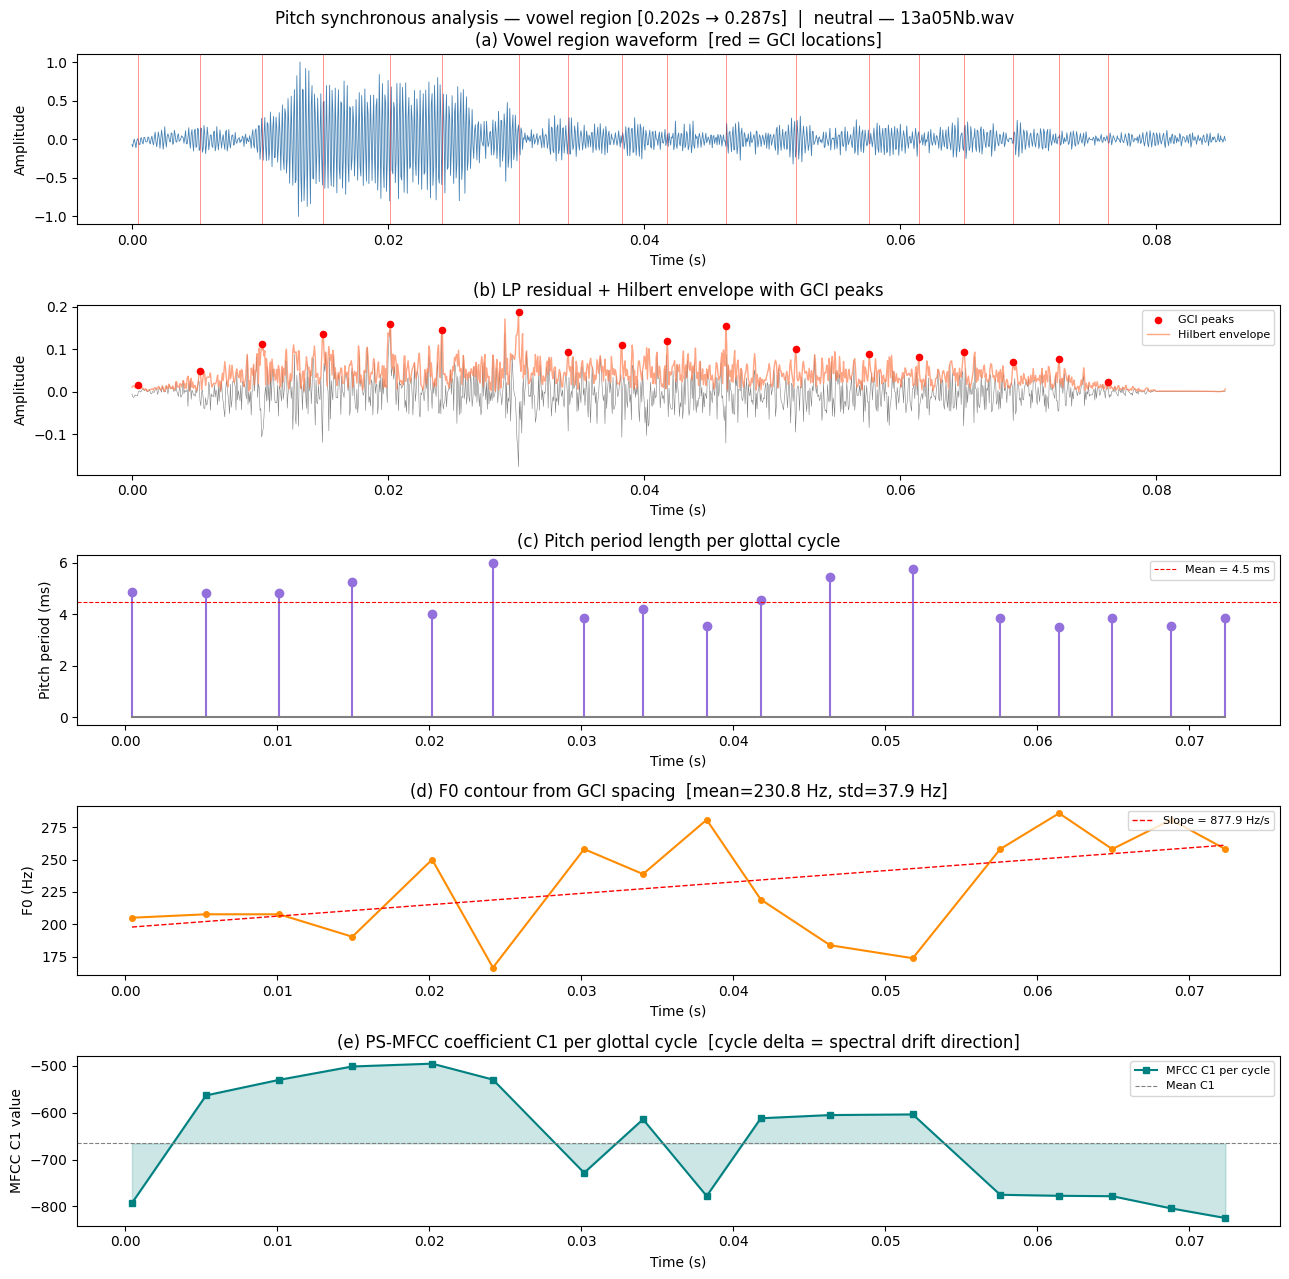


Pitch synchronous summary — neutral — 13a05Nb.wav
  Vowel region      : 0.202s → 0.287s  (85 ms)
  GCIs detected     : 18
  Pitch periods     : 17
  Mean pitch period : 4.46 ms
  F0 mean           : 230.8 Hz
  F0 std (jitter)   : 37.91 Hz
  F0 slope          : 877.9 Hz/s  (rising)
  C1 cycle delta    : -1.9955  (formants falling)


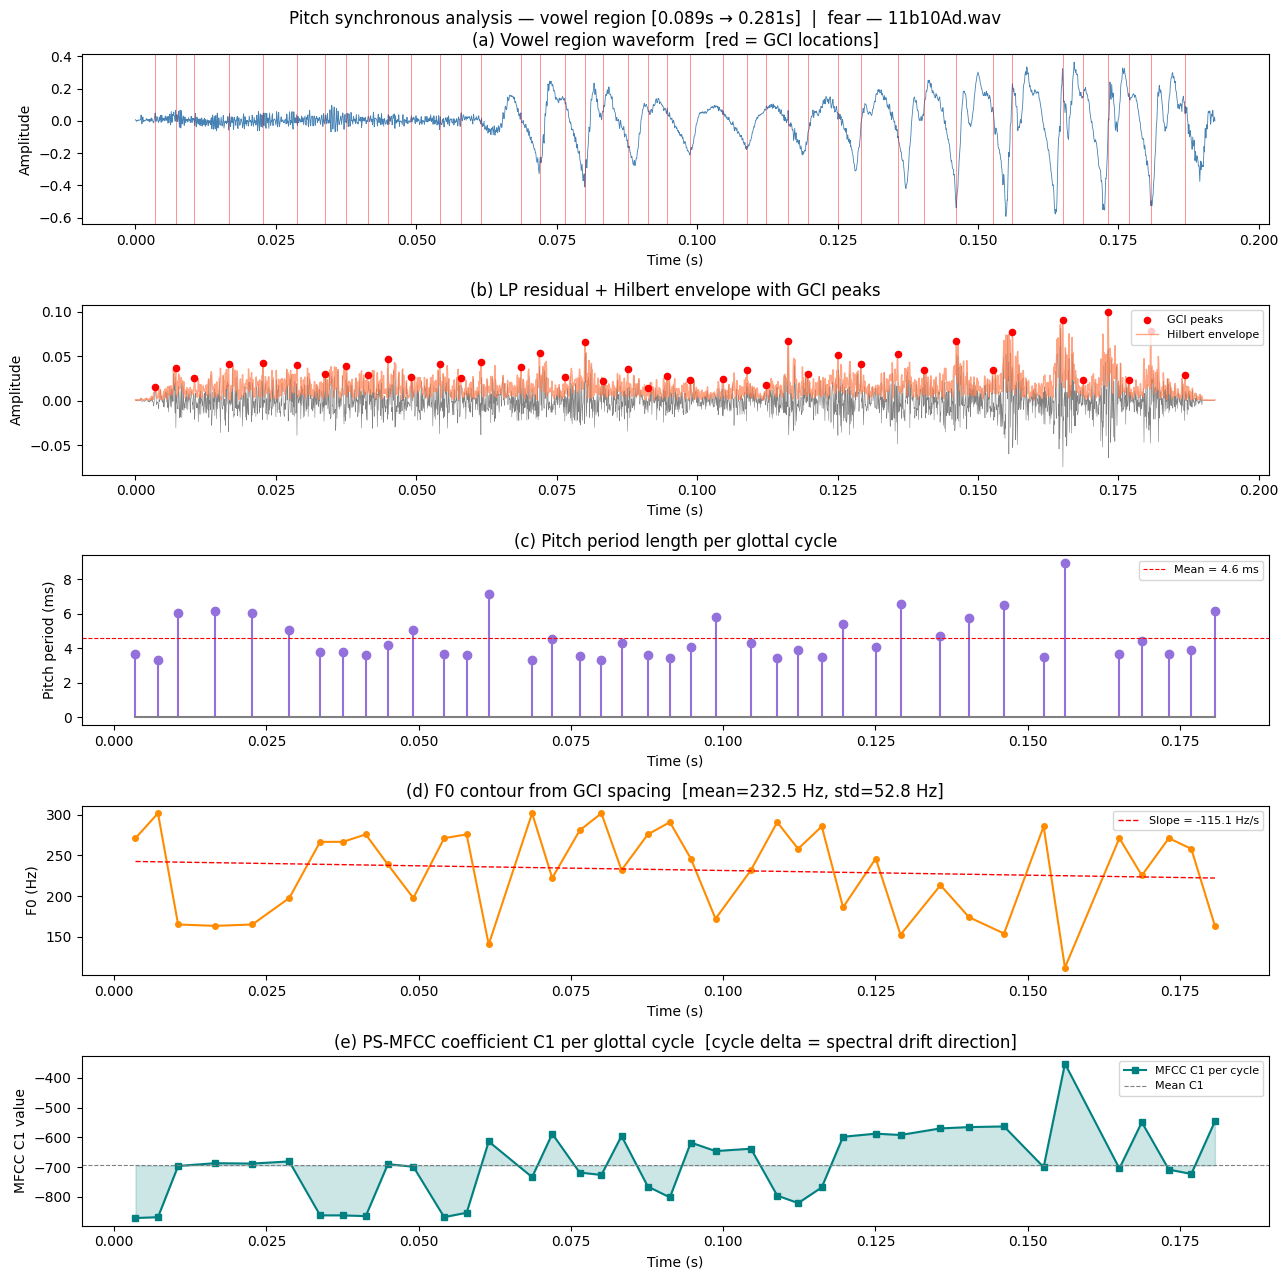


Pitch synchronous summary — fear — 11b10Ad.wav
  Vowel region      : 0.089s → 0.281s  (192 ms)
  GCIs detected     : 41
  Pitch periods     : 40
  Mean pitch period : 4.58 ms
  F0 mean           : 232.5 Hz
  F0 std (jitter)   : 52.80 Hz
  F0 slope          : -115.1 Hz/s  (falling)
  C1 cycle delta    : 8.3352  (formants rising)


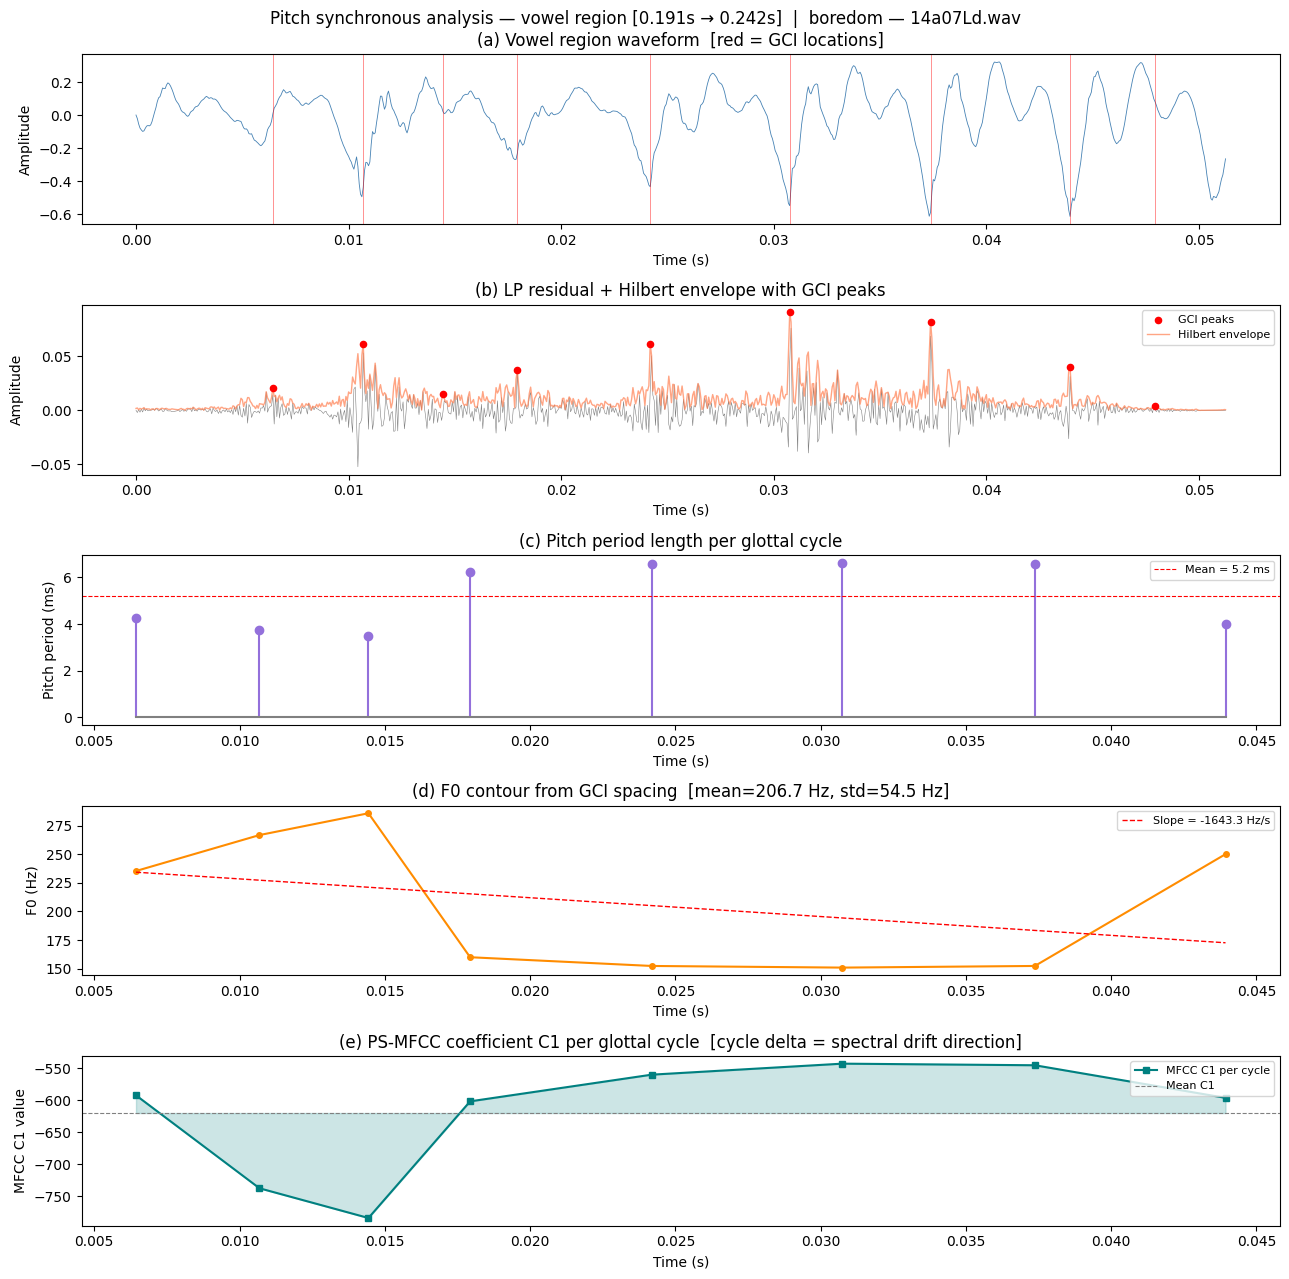


Pitch synchronous summary — boredom — 14a07Ld.wav
  Vowel region      : 0.191s → 0.242s  (51 ms)
  GCIs detected     : 9
  Pitch periods     : 8
  Mean pitch period : 5.19 ms
  F0 mean           : 206.7 Hz
  F0 std (jitter)   : 54.45 Hz
  F0 slope          : -1643.3 Hz/s  (falling)
  C1 cycle delta    : -0.5681  (formants falling)


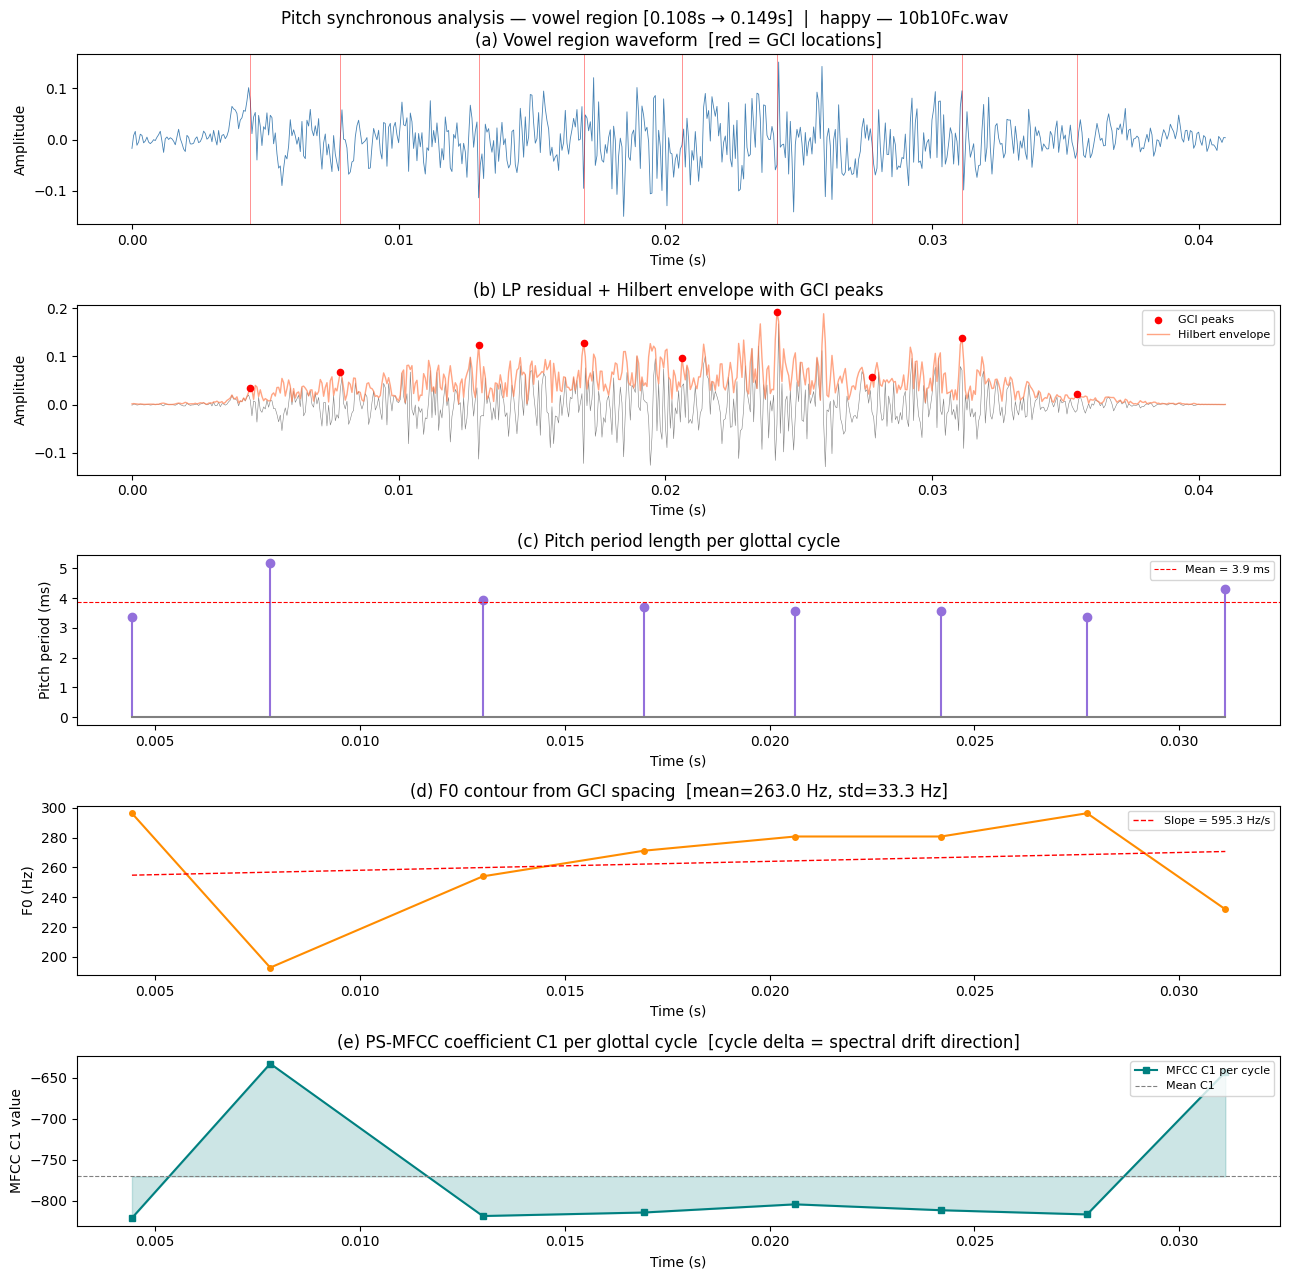


Pitch synchronous summary — happy — 10b10Fc.wav
  Vowel region      : 0.108s → 0.149s  (41 ms)
  GCIs detected     : 9
  Pitch periods     : 8
  Mean pitch period : 3.88 ms
  F0 mean           : 263.0 Hz
  F0 std (jitter)   : 33.34 Hz
  F0 slope          : 595.3 Hz/s  (rising)
  C1 cycle delta    : 25.4342  (formants rising)


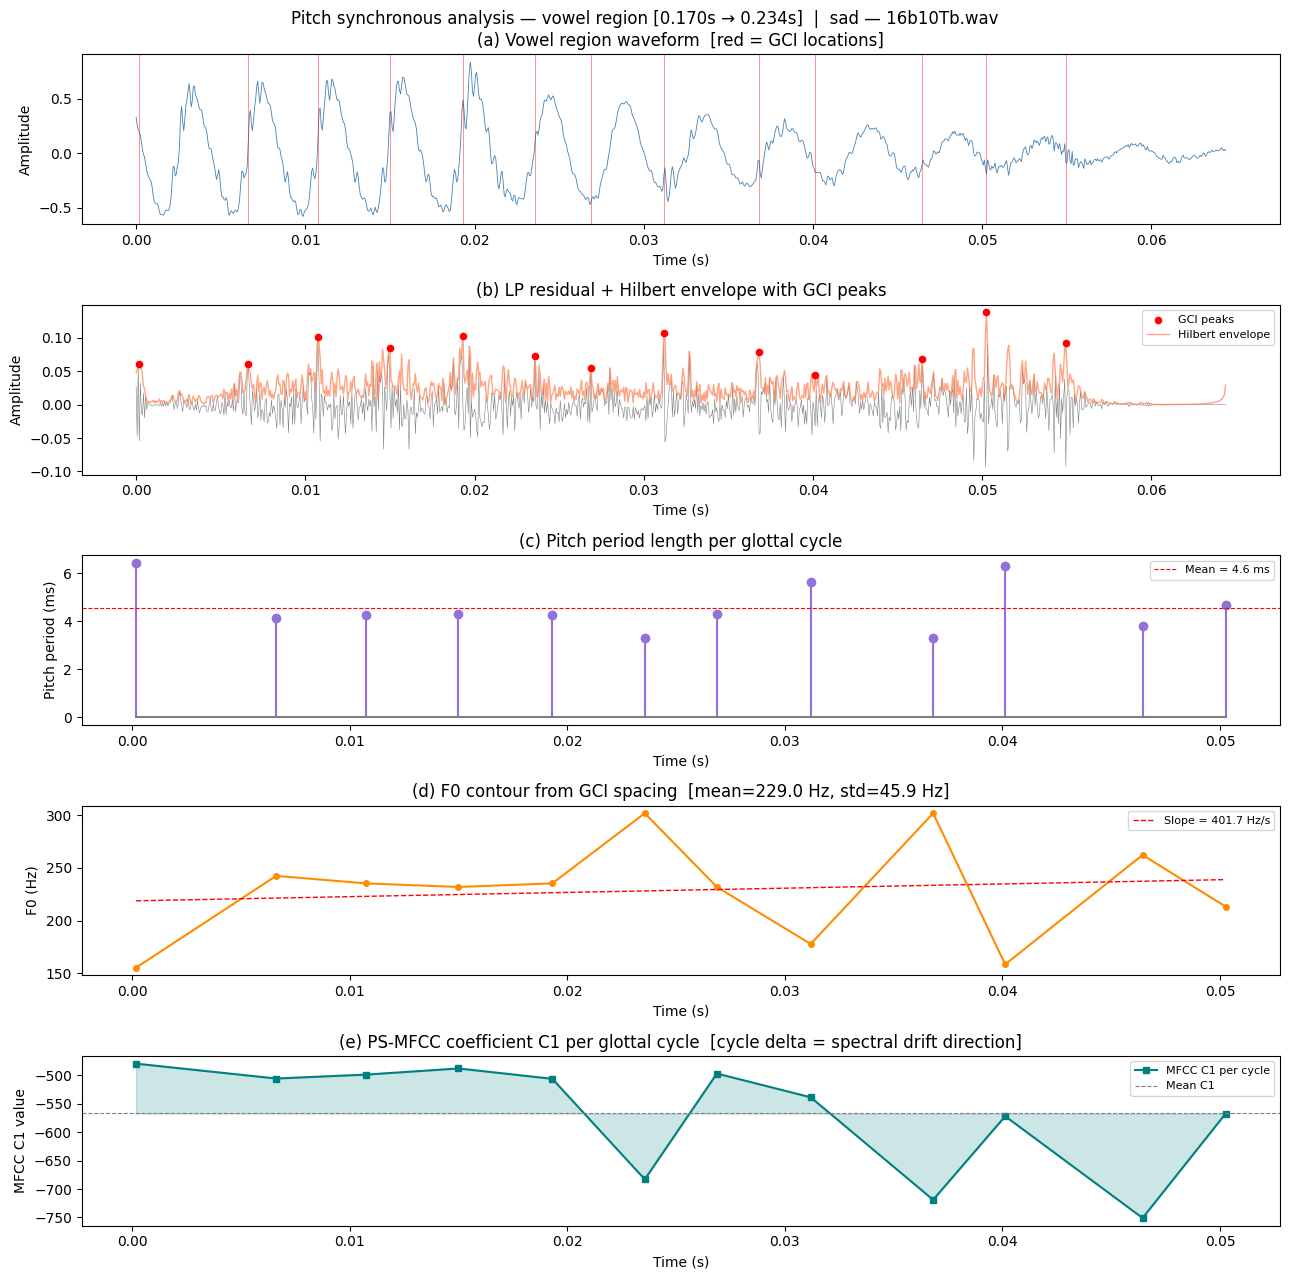


Pitch synchronous summary — sad — 16b10Tb.wav
  Vowel region      : 0.170s → 0.234s  (64 ms)
  GCIs detected     : 13
  Pitch periods     : 12
  Mean pitch period : 4.56 ms
  F0 mean           : 229.0 Hz
  F0 std (jitter)   : 45.90 Hz
  F0 slope          : 401.7 Hz/s  (rising)
  C1 cycle delta    : -8.0026  (formants falling)


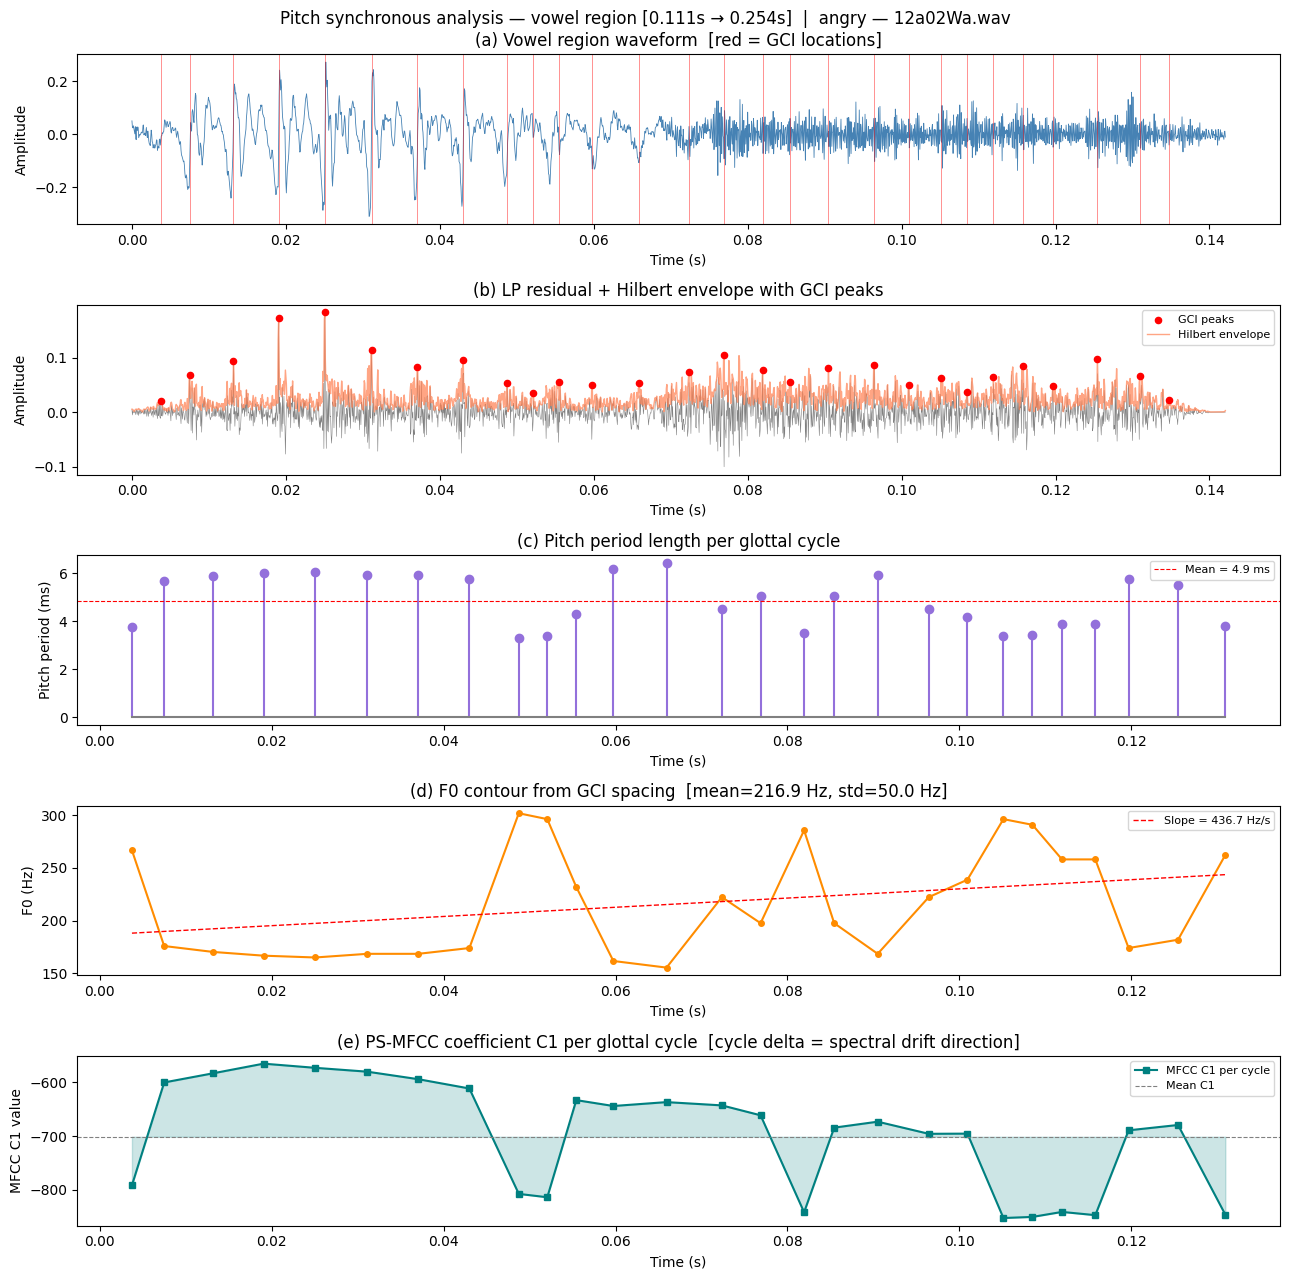


Pitch synchronous summary — angry — 12a02Wa.wav
  Vowel region      : 0.111s → 0.254s  (142 ms)
  GCIs detected     : 28
  Pitch periods     : 27
  Mean pitch period : 4.85 ms
  F0 mean           : 216.9 Hz
  F0 std (jitter)   : 49.96 Hz
  F0 slope          : 436.7 Hz/s  (rising)
  C1 cycle delta    : -2.1048  (formants falling)


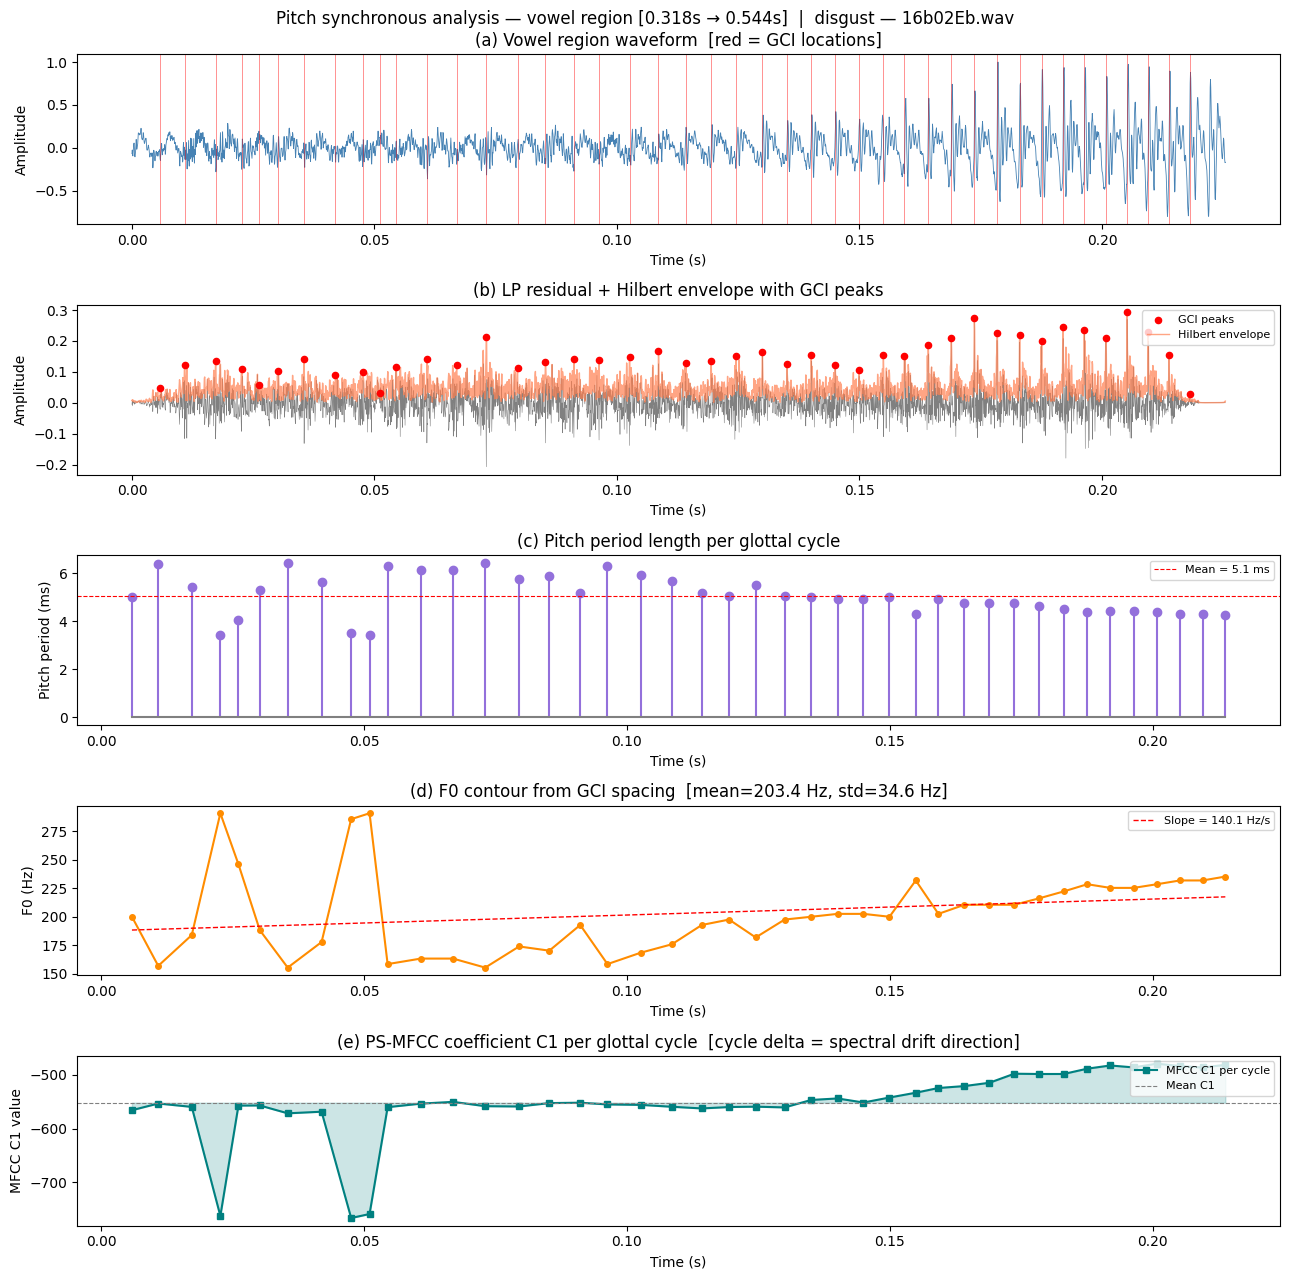


Pitch synchronous summary — disgust — 16b02Eb.wav
  Vowel region      : 0.318s → 0.544s  (226 ms)
  GCIs detected     : 43
  Pitch periods     : 42
  Mean pitch period : 5.05 ms
  F0 mean           : 203.4 Hz
  F0 std (jitter)   : 34.62 Hz
  F0 slope          : 140.1 Hz/s  (rising)
  C1 cycle delta    : 2.0576  (formants rising)


In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pitch_periods(signal, sr=16000, title=""):
    """
    Visualizes pitch synchronous analysis for one audio file:
    - Waveform with GCI markers
    - LP residual with GCI peaks
    - Hilbert envelope
    - Pitch period lengths over time
    - F0 contour over time
    """
    # ── Run the pipeline to get intermediates ────────────────
    regions = detect_vowel_regions_vop_vep(signal, sr)

    if len(regions) == 0:
        print("No vowel regions detected.")
        return

    # Use the first detected vowel region for illustration
    start, end = regions[0]
    seg = signal[start:end]

    if len(seg) < 256:
        print("First region too short, trying next...")
        for s, e in regions[1:]:
            seg = signal[s:e]
            start, end = s, e
            if len(seg) >= 256:
                break

    # ── Compute all intermediate signals ─────────────────────
    pre      = np.append(seg[0], seg[1:] - 0.97 * seg[:-1])
    frame_len = min(int(0.02 * sr), len(pre) // 2)
    hop_len   = frame_len // 2
    residual  = np.zeros_like(pre)
    win       = hamming(frame_len)

    for s in range(0, len(pre) - frame_len, hop_len):
        frame = pre[s:s+frame_len] * win
        try:
            lpc_coef  = librosa.lpc(frame,
                                     order=min(10, len(frame)//2 - 1))
            frame_res = lfilter(lpc_coef, [1.0], frame)
            residual[s:s+frame_len] += frame_res
        except Exception:
            continue

    he       = np.abs(hilbert(residual))
    min_dist = max(1, int(sr / 300))
    gcis, _  = find_peaks(he, distance=min_dist,
                            prominence=0.03 * np.max(he))

    # Filter by F0 range
    max_dist = int(sr / 60)
    if len(gcis) > 1:
        gaps       = np.diff(gcis)
        valid_mask = np.concatenate([[True], gaps <= max_dist])
        gcis       = gcis[valid_mask]

    # ── Compute pitch period and F0 from GCI spacing ─────────
    if len(gcis) < 2:
        print("Not enough GCIs detected in this region.")
        return

    periods    = np.diff(gcis)                        # samples
    period_ms  = periods / sr * 1000                  # milliseconds
    f0_vals    = sr / (periods.astype(float) + 1e-8)  # Hz
    gci_times  = gcis / sr                            # seconds
    period_times = gcis[:-1] / sr                     # one per gap

    t_seg = np.arange(len(seg)) / sr

    # ── Plot ─────────────────────────────────────────────────
    fig, axes = plt.subplots(5, 1, figsize=(13, 13), sharex=False)
    fig.suptitle(
        f"Pitch synchronous analysis — vowel region "
        f"[{start/sr:.3f}s → {end/sr:.3f}s]"
        + (f"  |  {title}" if title else ""),
        fontsize=12
    )

    # ── Panel 1: Waveform with GCI markers ───────────────────
    axes[0].plot(t_seg, seg, lw=0.6, color='steelblue')
    for g in gcis:
        axes[0].axvline(g/sr, color='red', lw=0.6, alpha=0.5)
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title("(a) Vowel region waveform  [red = GCI locations]")
    axes[0].set_xlabel("Time (s)")

    # ── Panel 2: LP residual with GCI peaks ──────────────────
    axes[1].plot(t_seg[:len(residual)], residual, lw=0.4, color='gray')
    axes[1].scatter(gcis/sr, he[gcis], color='red', s=20, zorder=5,
                    label='GCI peaks')
    axes[1].set_ylabel("Amplitude")
    axes[1].set_title("(b) LP residual + Hilbert envelope with GCI peaks")
    axes[1].plot(t_seg[:len(he)], he, lw=1, color='coral',
                 alpha=0.7, label='Hilbert envelope')
    axes[1].legend(fontsize=8, loc='upper right')
    axes[1].set_xlabel("Time (s)")

    # ── Panel 3: Pitch period lengths ────────────────────────
    axes[2].stem(period_times, period_ms,
                 linefmt='mediumpurple', markerfmt='o',
                 basefmt='gray')
    axes[2].axhline(np.mean(period_ms), color='red', ls='--',
                    lw=0.8, label=f'Mean = {np.mean(period_ms):.1f} ms')
    axes[2].set_ylabel("Pitch period (ms)")
    axes[2].set_title("(c) Pitch period length per glottal cycle")
    axes[2].legend(fontsize=8, loc='upper right')
    axes[2].set_xlabel("Time (s)")

    # ── Panel 4: F0 contour ──────────────────────────────────
    axes[3].plot(period_times, f0_vals, 'o-',
                 color='darkorange', lw=1.5, ms=4)

    # Fit and plot F0 slope
    if len(period_times) > 1:
        slope, intercept = np.polyfit(period_times, f0_vals, 1)
        fit_line = slope * period_times + intercept
        axes[3].plot(period_times, fit_line, 'r--', lw=1,
                     label=f'Slope = {slope:.1f} Hz/s')
        axes[3].legend(fontsize=8, loc='upper right')

    axes[3].set_ylabel("F0 (Hz)")
    axes[3].set_title(
        f"(d) F0 contour from GCI spacing  "
        f"[mean={np.mean(f0_vals):.1f} Hz, "
        f"std={np.std(f0_vals):.1f} Hz]"
    )
    axes[3].set_xlabel("Time (s)")

    # ── Panel 5: PS-MFCC C1 across cycles ────────────────────
    # Shows how the first MFCC coefficient evolves cycle by cycle
    c1_per_cycle = []
    for i in range(len(gcis) - 1):
        s_idx   = gcis[i]
        e_idx   = gcis[i+1]
        period_len = e_idx - s_idx
        extra   = period_len // 2
        ws      = max(0, s_idx - extra)
        we      = min(len(seg), e_idx + extra)
        frame   = seg[ws:we]
        if len(frame) < 64:
            c1_per_cycle.append(np.nan)
            continue
        n_fft = safe_n_fft(len(frame))
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                mfcc = librosa.feature.mfcc(
                    y=frame, sr=sr, n_mfcc=4,
                    n_fft=n_fft, hop_length=max(1, period_len//4)
                )
            c1_per_cycle.append(np.mean(mfcc[0]))
        except Exception:
            c1_per_cycle.append(np.nan)

    c1_arr = np.array(c1_per_cycle)
    valid  = ~np.isnan(c1_arr)

    if valid.sum() > 1:
        axes[4].plot(period_times[valid], c1_arr[valid],
                     's-', color='teal', lw=1.5, ms=5,
                     label='MFCC C1 per cycle')
        # Shade the drift direction
        axes[4].fill_between(
            period_times[valid],
            np.nanmean(c1_arr),
            c1_arr[valid],
            alpha=0.2, color='teal'
        )
        axes[4].axhline(np.nanmean(c1_arr), color='gray',
                        ls='--', lw=0.8, label='Mean C1')
        axes[4].legend(fontsize=8, loc='upper right')

    axes[4].set_ylabel("MFCC C1 value")
    axes[4].set_title(
        "(e) PS-MFCC coefficient C1 per glottal cycle  "
        "[cycle delta = spectral drift direction]"
    )
    axes[4].set_xlabel("Time (s)")

    plt.tight_layout()
    plt.show()

    # ── Print summary stats ───────────────────────────────────
    print(f"\nPitch synchronous summary — {title}")
    print(f"  Vowel region      : {start/sr:.3f}s → {end/sr:.3f}s  "
          f"({(end-start)/sr*1000:.0f} ms)")
    print(f"  GCIs detected     : {len(gcis)}")
    print(f"  Pitch periods     : {len(periods)}")
    print(f"  Mean pitch period : {np.mean(period_ms):.2f} ms")
    print(f"  F0 mean           : {np.mean(f0_vals):.1f} Hz")
    print(f"  F0 std (jitter)   : {np.std(f0_vals):.2f} Hz")
    if len(period_times) > 1:
        slope, _ = np.polyfit(period_times, f0_vals, 1)
        direction = "rising" if slope > 0 else "falling"
        print(f"  F0 slope          : {slope:.1f} Hz/s  ({direction})")
    if valid.sum() > 1:
        cycle_delta = np.nanmean(np.diff(c1_arr[valid]))
        print(f"  C1 cycle delta    : {cycle_delta:.4f}  "
              f"({'formants rising' if cycle_delta > 0 else 'formants falling'})")


# ── Run on one sample per emotion ────────────────────────────
for emotion, file_path in sample_files.items():
    sig, _ = librosa.load(file_path, sr=16000)
    plot_pitch_periods(sig, sr=16000,
                       title=f"{emotion} — {os.path.basename(file_path)}")